# Sensitivity Analysis — Viscous Damping — Direction 45°

This notebook analyses the OrcaFlex sensitivity simulations.

**Per simulation it calculates:**
- Significant amplitude (mean of highest 1/3 peaks) for heave, roll, pitch
- Standard deviation (from OrcaFlex output)

**Output:**
- `sensitivity_results_45deg.xlsx` — all results with % difference vs reference
- PNG plots — time series (200–300 s) and bar charts of % difference


In [1]:
# ============================================================
# 1. Imports
# ============================================================
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

print('Imports OK')

Imports OK


In [2]:
# ============================================================
# 2. Paths — ADJUST TO YOUR FOLDER
# ============================================================
INPUT_FILE   = Path(r'C:\Users\verav\Desktop\Studie\Afstuderen\Simulaties\Sensitivity1\Input45_sensitivity1.xlsx')
RESULTS_FILE = Path(r'C:\Users\verav\Desktop\Studie\Afstuderen\Simulaties\Sensitivity1\Results45_sensitivity1.xlsx')

OUTPUT_DIR   = Path(r'C:\Users\verav\Desktop\Studie\Afstuderen\Simulaties\Sensitivity1\analysis')
PLOTS_DIR    = OUTPUT_DIR / 'plots'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

# Time range for time-series plots [s]
T_PLOT_START = 200.0
T_PLOT_END   = 300.0

# Time step [s] — OrcaFlex default is 0.1 s, adjust if needed
DT = 0.1

print('Paths set')

Paths set


In [3]:
# ============================================================
# 3. Load input (case metadata)
# ============================================================
inp_raw = pd.read_excel(INPUT_FILE, header=2, skiprows=[3])
inp_raw.columns = [
    '%filename', '#', '%Hs', '%Tp', '%Tz', '%Direction',
    '%Damp_Heave', '%Damp_Roll', '%Damp_Pitch',
    '%Lin_Heave', '%Quad_Heave',
    '%Lin_Roll',  '%Quad_Roll',
    '%Lin_Pitch', '%Quad_Pitch',
]

# Keep only real data rows
meta = inp_raw.dropna(subset=['%Hs']).reset_index(drop=True)
meta['#'] = meta['#'].astype(int)

# Keep only direction 45° cases
meta = meta[meta['%Direction'] == 45].reset_index(drop=True)

print(f'Total cases in input: {len(meta)}')
meta[['%filename', '%Hs', '%Tp', '%Direction', '%Damp_Heave', '%Damp_Roll', '%Damp_Pitch']].head(7)

Total cases in input: 68


,%filename,%Hs,%Tp,%Direction,%Damp_Heave,%Damp_Roll,%Damp_Pitch
0,Case_142_H1_T4.08_dir45_heavequadhigh_pitchlow...,1,4.08,45,quadhigh,low,low
1,Case_143_H1_T4.08_dir45_heavelow_pitchlow_roll...,1,4.08,45,low,linhigh,low
2,Case_144_H1_T4.08_dir45_heavelow_pitchlow_roll...,1,4.08,45,low,quadhigh,low
3,Case_145_H1_T4.08_dir45_heavelow_pitchlinhigh_...,1,4.08,45,low,low,linhigh
4,Case_146_H1_T4.08_dir45_heavelow_pitchquadhigh...,1,4.08,45,low,low,quadhigh
5,Case_147_H2_T4.08_dir45_heavelow_pitchlow_roll...,2,4.08,45,low,low,low
6,Case_148_H2_T4.08_dir45_heavelinhigh_pitchlow_...,2,4.08,45,linhigh,low,low


In [4]:
# ============================================================
# 4. Load results (time series + mean + std per simulation)
# ============================================================
res_raw = pd.read_excel(RESULTS_FILE, header=0)

n_cols      = res_raw.shape[1]     # total columns
cols_per_sim = 9                   # heave_ts, pitch_ts, roll_ts, heave_mean, pitch_mean, roll_mean, heave_std, pitch_std, roll_std
n_sims_full = n_cols // cols_per_sim

print(f'Results columns: {n_cols}  →  {n_sims_full} complete simulations in results file')
print(f'Input cases:     {len(meta)}')

if n_sims_full < len(meta):
    print(f'WARNING: {len(meta) - n_sims_full} cases missing from results file!')

# Build time vector from number of rows
n_rows  = res_raw.shape[0]
time    = np.arange(n_rows) * DT
print(f'Time series length: {n_rows} steps  →  {n_rows * DT:.1f} s')

Results columns: 630  →  70 complete simulations in results file
Input cases:     68
Time series length: 3080 steps  →  308.0 s


In [5]:
# ============================================================
# 5. Helper: significant amplitude (mean of highest 1/3 peaks)
# ============================================================
def significant_amplitude(ts: np.ndarray) -> float:
    """
    Returns the mean of the highest 1/3 of positive peaks in the signal.
    Uses absolute values so it works for symmetric oscillations.
    """
    ts = np.asarray(ts, dtype=float)
    ts = ts[~np.isnan(ts)]
    if len(ts) < 3:
        return np.nan

    # Find peaks of |signal|
    peaks_idx, _ = find_peaks(np.abs(ts))
    if len(peaks_idx) == 0:
        return np.nan

    peak_vals = np.abs(ts[peaks_idx])
    peak_vals_sorted = np.sort(peak_vals)[::-1]  # descending

    n_top = max(1, len(peak_vals_sorted) // 3)
    return float(np.mean(peak_vals_sorted[:n_top]))

print('significant_amplitude() defined')

significant_amplitude() defined


In [6]:
# ============================================================
# 6. Parse all results into a clean dataframe
# ============================================================
records = []

for sim_idx in range(n_sims_full):
    col_start = sim_idx * cols_per_sim

    # Time series
    heave_ts = res_raw.iloc[:, col_start + 0].values
    pitch_ts = res_raw.iloc[:, col_start + 1].values
    roll_ts  = res_raw.iloc[:, col_start + 2].values

    # Statistics from OrcaFlex (row 0)
    heave_mean = res_raw.iloc[0, col_start + 3]
    pitch_mean = res_raw.iloc[0, col_start + 4]
    roll_mean  = res_raw.iloc[0, col_start + 5]
    heave_std  = res_raw.iloc[0, col_start + 6]
    pitch_std  = res_raw.iloc[0, col_start + 7]
    roll_std   = res_raw.iloc[0, col_start + 8]

    # Significant amplitude (whole sim)
    heave_sa = significant_amplitude(heave_ts)
    pitch_sa = significant_amplitude(pitch_ts)
    roll_sa  = significant_amplitude(roll_ts)

    # Metadata from input
    m = meta.iloc[sim_idx] if sim_idx < len(meta) else {}

    records.append({
        'sim_idx':       sim_idx,
        'filename':      m.get('%filename', f'sim_{sim_idx:03d}'),
        'Hs':            m.get('%Hs'),
        'Tp':            m.get('%Tp'),
        'Tz':            m.get('%Tz'),
        'Direction':     m.get('%Direction'),
        'Damp_Heave':    m.get('%Damp_Heave'),
        'Damp_Roll':     m.get('%Damp_Roll'),
        'Damp_Pitch':    m.get('%Damp_Pitch'),
        'Lin_Heave':     m.get('%Lin_Heave'),
        'Quad_Heave':    m.get('%Quad_Heave'),
        'Lin_Roll':      m.get('%Lin_Roll'),
        'Quad_Roll':     m.get('%Quad_Roll'),
        'Lin_Pitch':     m.get('%Lin_Pitch'),
        'Quad_Pitch':    m.get('%Quad_Pitch'),
        # Statistics
        'heave_mean':    heave_mean,
        'pitch_mean':    pitch_mean,
        'roll_mean':     roll_mean,
        'heave_std':     heave_std,
        'pitch_std':     pitch_std,
        'roll_std':      roll_std,
        'heave_sig_amp': heave_sa,
        'pitch_sig_amp': pitch_sa,
        'roll_sig_amp':  roll_sa,
        # Store time series for later plotting
        '_heave_ts':     heave_ts,
        '_pitch_ts':     pitch_ts,
        '_roll_ts':      roll_ts,
    })

results = pd.DataFrame(records)
print(f'Parsed {len(results)} simulations')
results[['filename', 'Hs', 'Tp', 'Direction', 'Damp_Heave', 'Damp_Roll', 'Damp_Pitch',
         'heave_sig_amp', 'heave_std', 'pitch_sig_amp', 'pitch_std', 'roll_sig_amp', 'roll_std']].head(7)

Parsed 70 simulations


,filename,Hs,Tp,Direction,Damp_Heave,Damp_Roll,Damp_Pitch,heave_sig_amp,heave_std,pitch_sig_amp,pitch_std,roll_sig_amp,roll_std
0,Case_142_H1_T4.08_dir45_heavequadhigh_pitchlow...,1.0,4.08,45.0,quadhigh,low,low,1.123837,0.108451,1.005270,0.409563,1.262702,0.625102
1,Case_143_H1_T4.08_dir45_heavelow_pitchlow_roll...,1.0,4.08,45.0,low,linhigh,low,1.104361,0.098485,1.005222,0.409361,1.262419,0.625003
2,Case_144_H1_T4.08_dir45_heavelow_pitchlow_roll...,1.0,4.08,45.0,low,quadhigh,low,1.114052,0.103469,1.005401,0.409494,1.262503,0.625053
3,Case_145_H1_T4.08_dir45_heavelow_pitchlinhigh_...,1.0,4.08,45.0,low,low,linhigh,1.124162,0.108658,1.004449,0.409165,1.241969,0.616470
4,Case_146_H1_T4.08_dir45_heavelow_pitchquadhigh...,1.0,4.08,45.0,low,low,quadhigh,1.123987,0.108543,1.004897,0.409380,1.249612,0.621266
5,Case_147_H2_T4.08_dir45_heavelow_pitchlow_roll...,2.0,4.08,45.0,low,low,low,1.123919,0.108471,0.996123,0.404315,1.262486,0.625017
6,Case_148_H2_T4.08_dir45_heavelinhigh_pitchlow_...,2.0,4.08,45.0,linhigh,low,low,1.123845,0.108452,1.004270,0.408988,1.262665,0.625087


In [7]:
# ============================================================
# 7. Calculate % difference vs reference (all low)
# ============================================================
is_ref = (
    (results['Damp_Heave'] == 'low') &
    (results['Damp_Roll']  == 'low') &
    (results['Damp_Pitch'] == 'low')
)

ref_df = results[is_ref].set_index(['Hs', 'Tp', 'Direction'])

metrics = ['heave_sig_amp', 'heave_std', 'pitch_sig_amp', 'pitch_std', 'roll_sig_amp', 'roll_std']

for metric in metrics:
    pct_col = f'{metric}_pct'
    results[pct_col] = results.apply(
        lambda row: (
            (row[metric] - ref_df.loc[(row['Hs'], row['Tp'], row['Direction']), metric])
            / ref_df.loc[(row['Hs'], row['Tp'], row['Direction']), metric] * 100
            if (row['Hs'], row['Tp'], row['Direction']) in ref_df.index else np.nan
        ),
        axis=1
    )

print('% differences calculated')
results[['filename', 'heave_sig_amp_pct', 'pitch_sig_amp_pct', 'roll_sig_amp_pct']].head(7)

% differences calculated


,filename,heave_sig_amp_pct,pitch_sig_amp_pct,roll_sig_amp_pct
0,Case_142_H1_T4.08_dir45_heavequadhigh_pitchlow...,NaN,NaN,NaN
1,Case_143_H1_T4.08_dir45_heavelow_pitchlow_roll...,NaN,NaN,NaN
2,Case_144_H1_T4.08_dir45_heavelow_pitchlow_roll...,NaN,NaN,NaN
3,Case_145_H1_T4.08_dir45_heavelow_pitchlinhigh_...,NaN,NaN,NaN
4,Case_146_H1_T4.08_dir45_heavelow_pitchquadhigh...,NaN,NaN,NaN
5,Case_147_H2_T4.08_dir45_heavelow_pitchlow_roll...,0.000000,0.000000,0.000000
6,Case_148_H2_T4.08_dir45_heavelinhigh_pitchlow_...,-0.006643,0.817878,0.014185


In [8]:
# ============================================================
# 8. Save results to Excel
# ============================================================
# Drop internal time series columns before saving
export_cols = [c for c in results.columns if not c.startswith('_')]
results[export_cols].to_excel(OUTPUT_DIR / 'sensitivity_results_45deg.xlsx', index=False)
print(f'Results saved → {OUTPUT_DIR / "sensitivity_results_45deg.xlsx"}')

Results saved → C:\Users\verav\Desktop\Studie\Afstuderen\Simulaties\Sensitivity1\analysis\sensitivity_results_45deg.xlsx


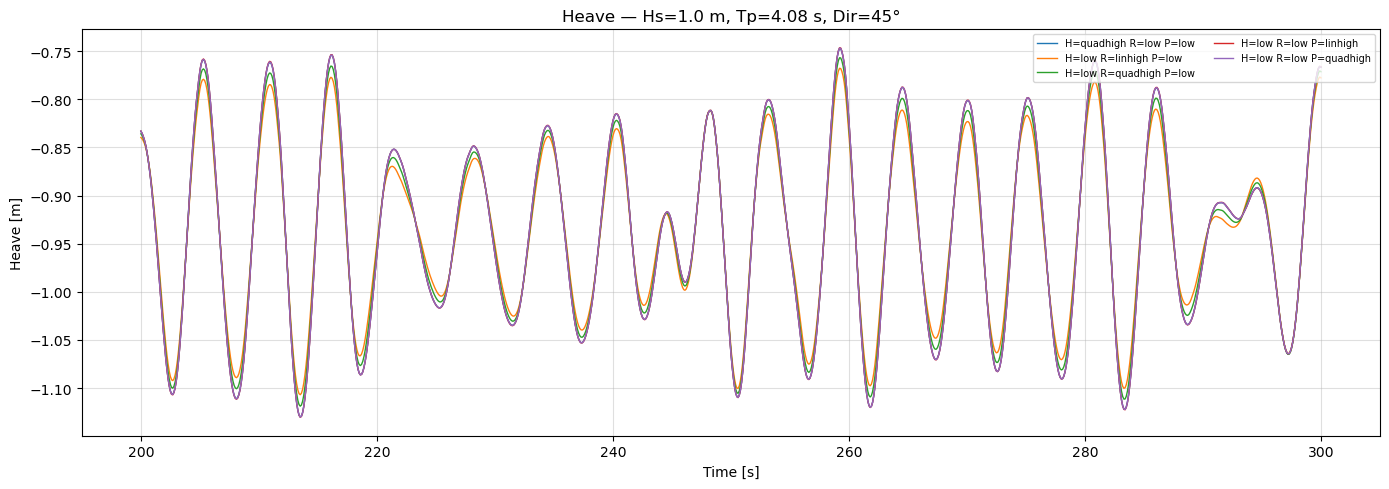

Saved: ts_heave_Hs1.0_Tp4.08_dir45.png


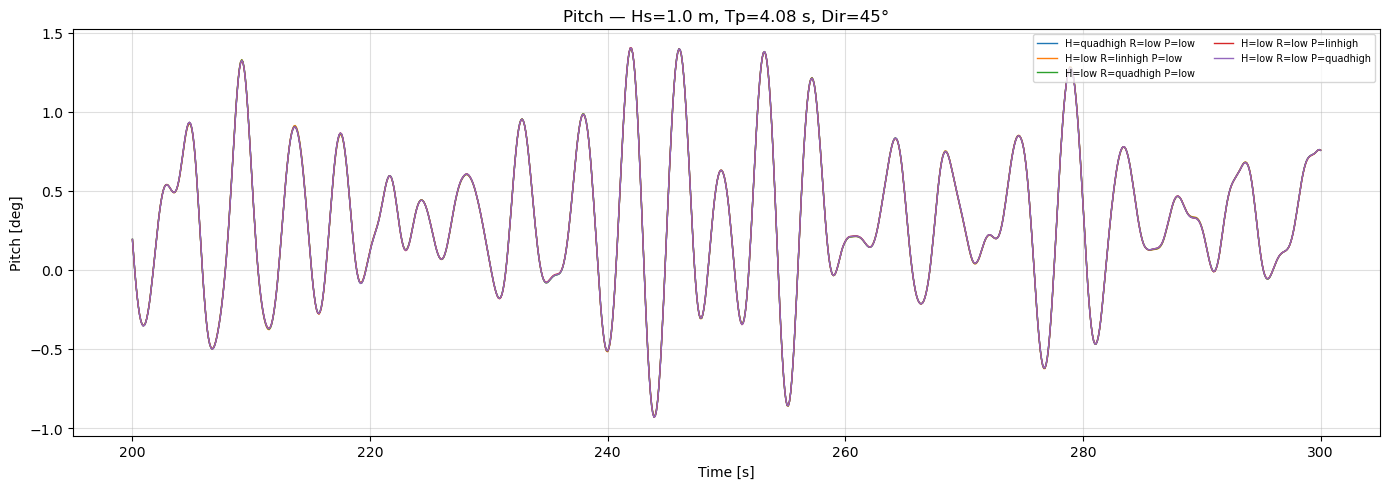

Saved: ts_pitch_Hs1.0_Tp4.08_dir45.png


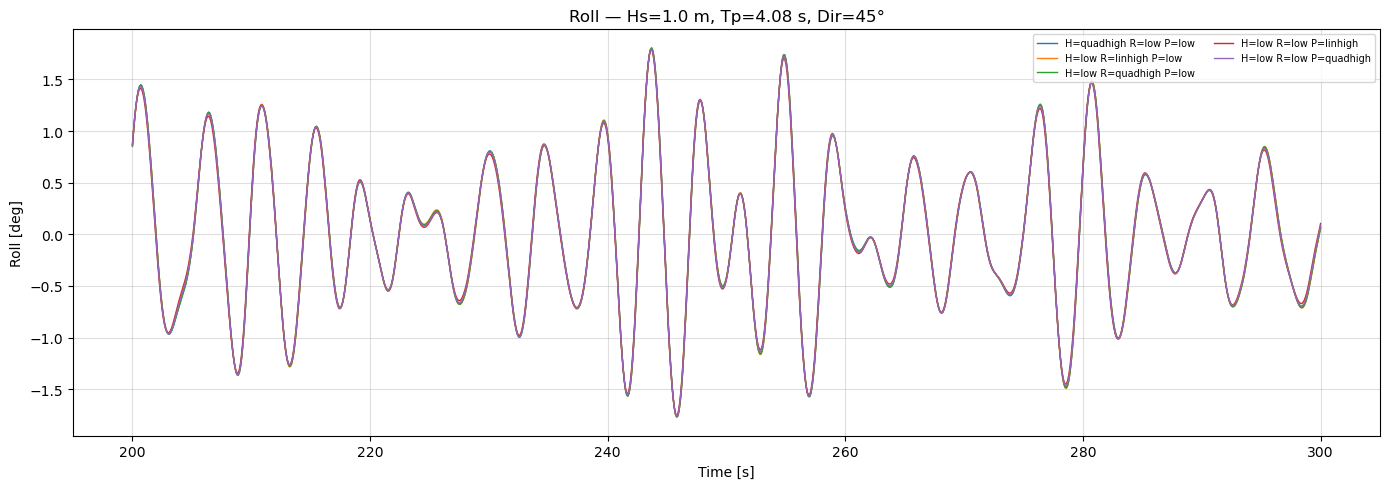

Saved: ts_roll_Hs1.0_Tp4.08_dir45.png


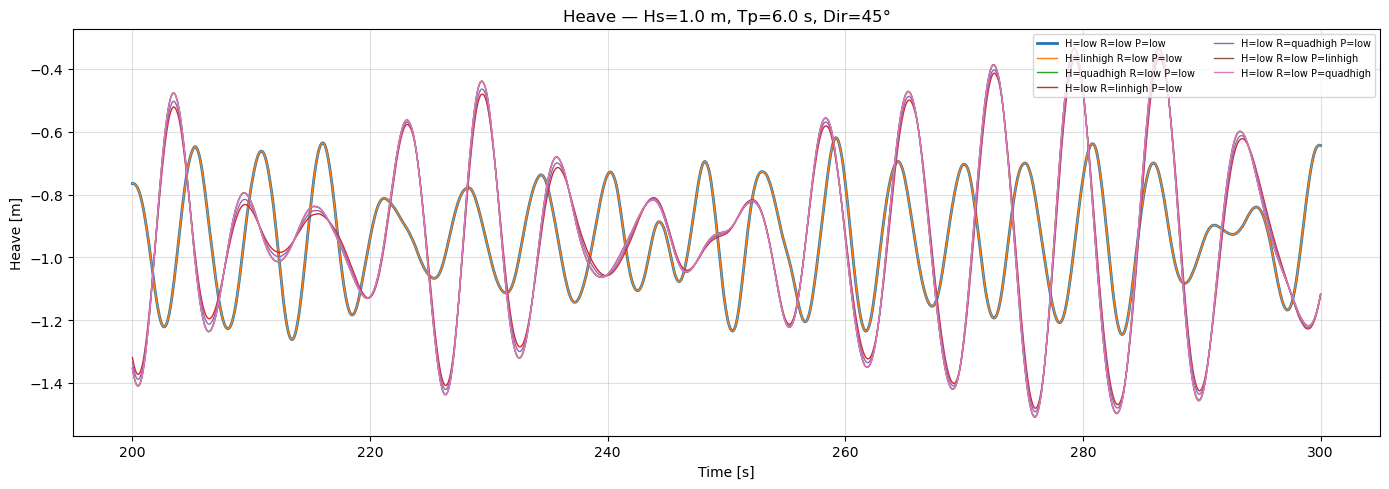

Saved: ts_heave_Hs1.0_Tp6.0_dir45.png


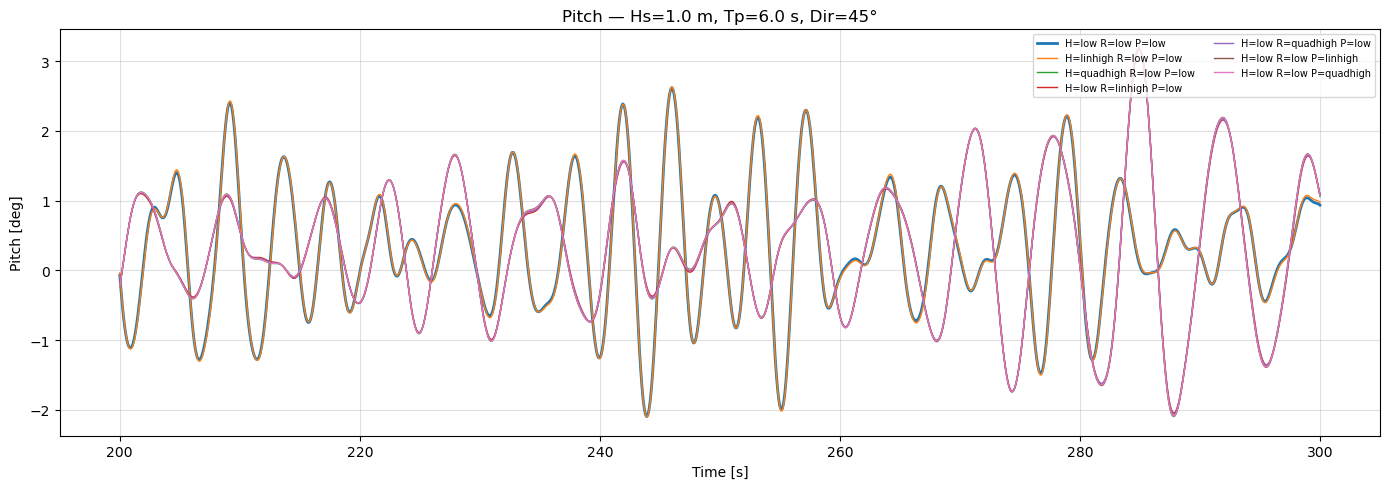

Saved: ts_pitch_Hs1.0_Tp6.0_dir45.png


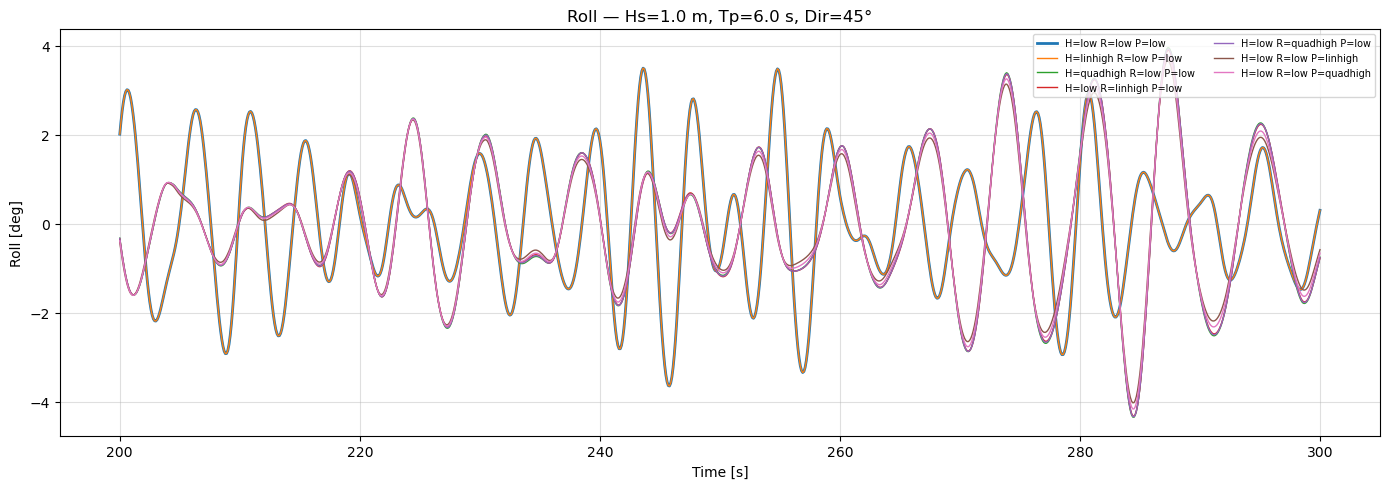

Saved: ts_roll_Hs1.0_Tp6.0_dir45.png


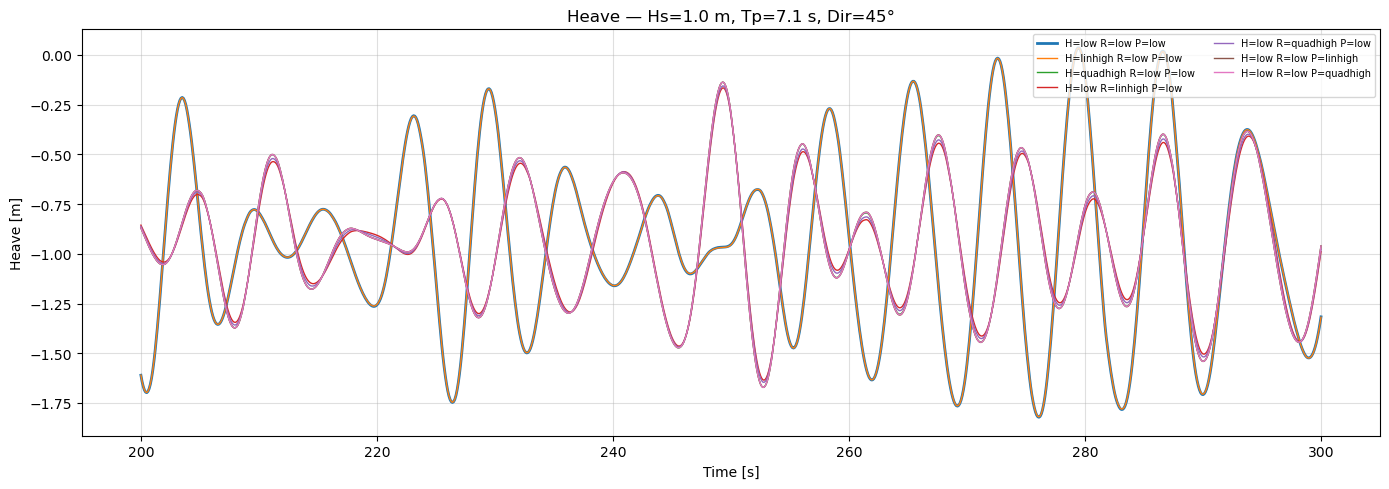

Saved: ts_heave_Hs1.0_Tp7.1_dir45.png


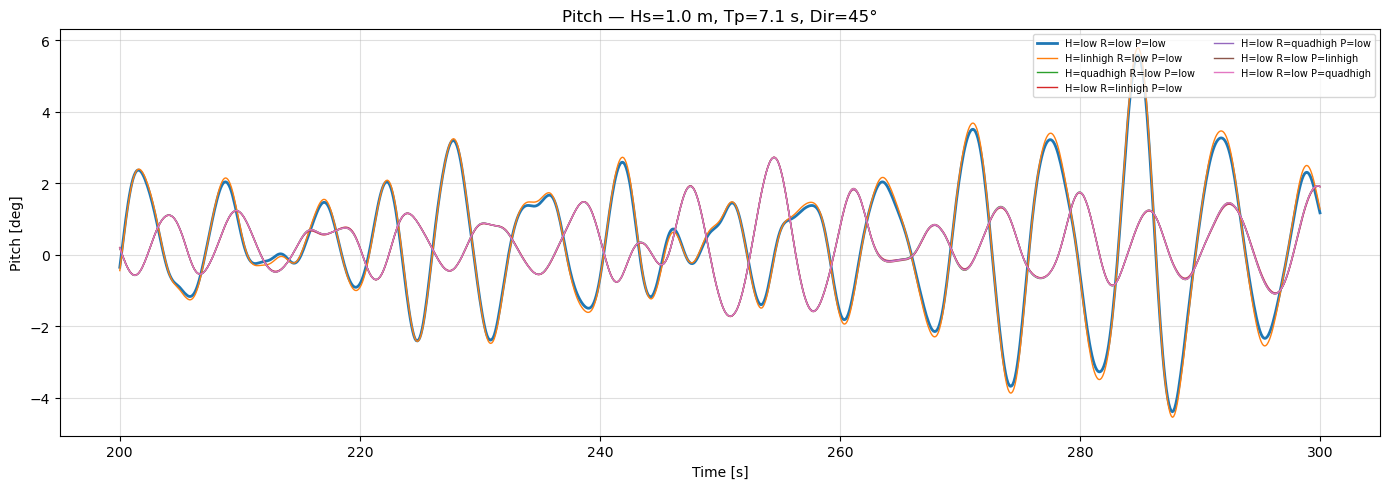

Saved: ts_pitch_Hs1.0_Tp7.1_dir45.png


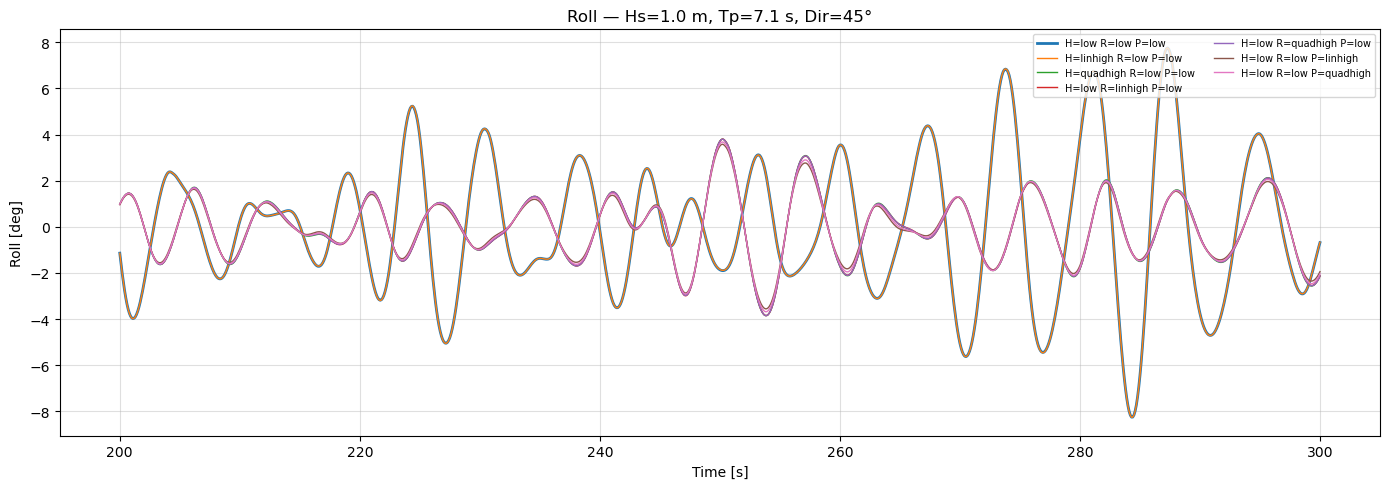

Saved: ts_roll_Hs1.0_Tp7.1_dir45.png


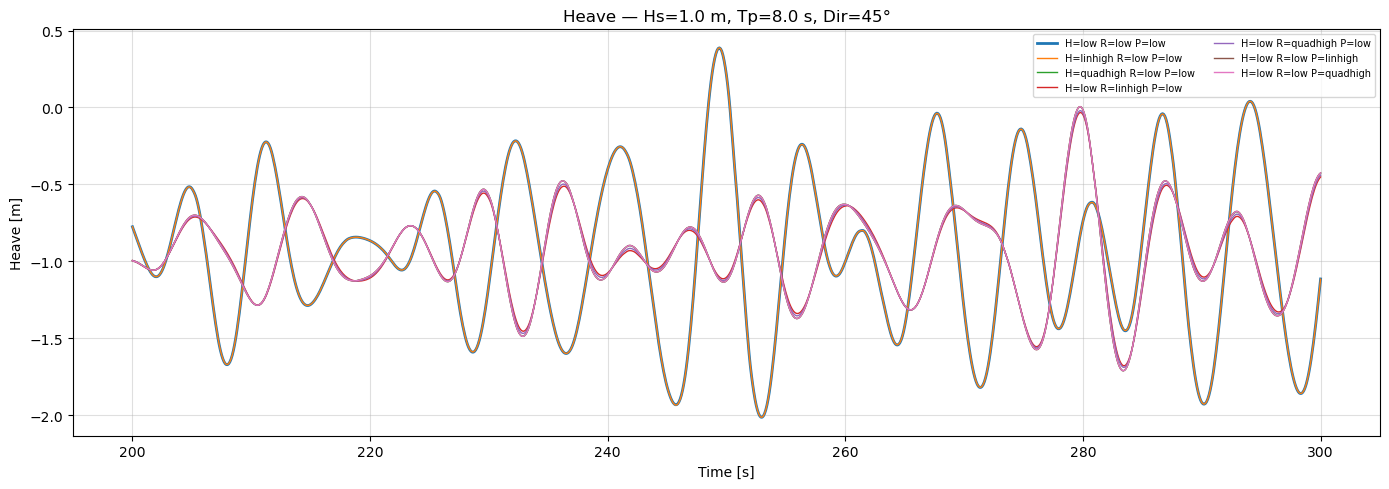

Saved: ts_heave_Hs1.0_Tp8.0_dir45.png


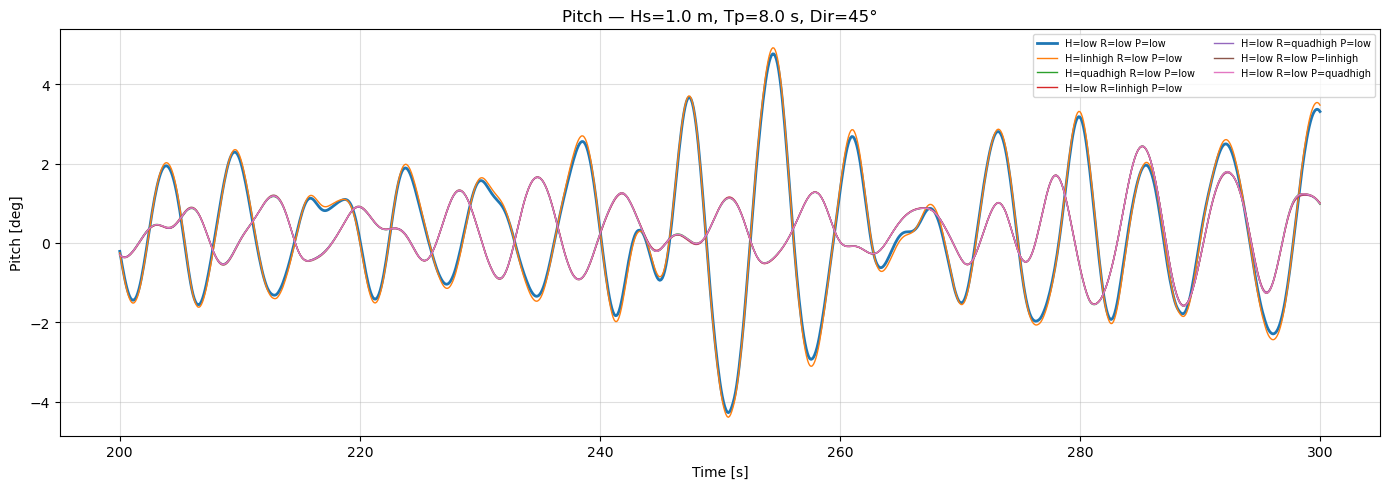

Saved: ts_pitch_Hs1.0_Tp8.0_dir45.png


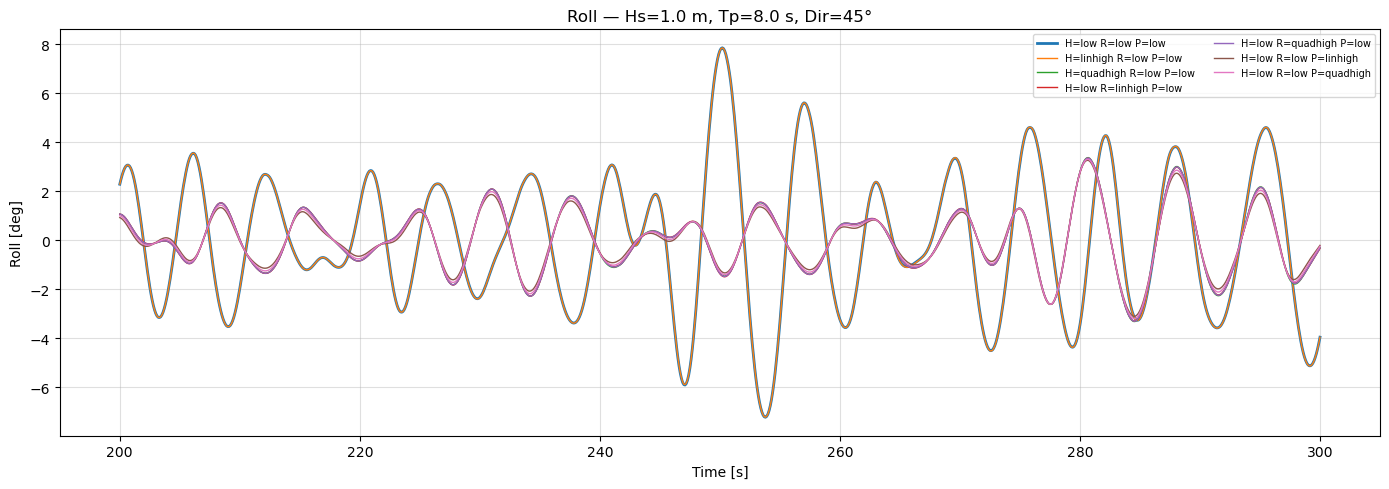

Saved: ts_roll_Hs1.0_Tp8.0_dir45.png


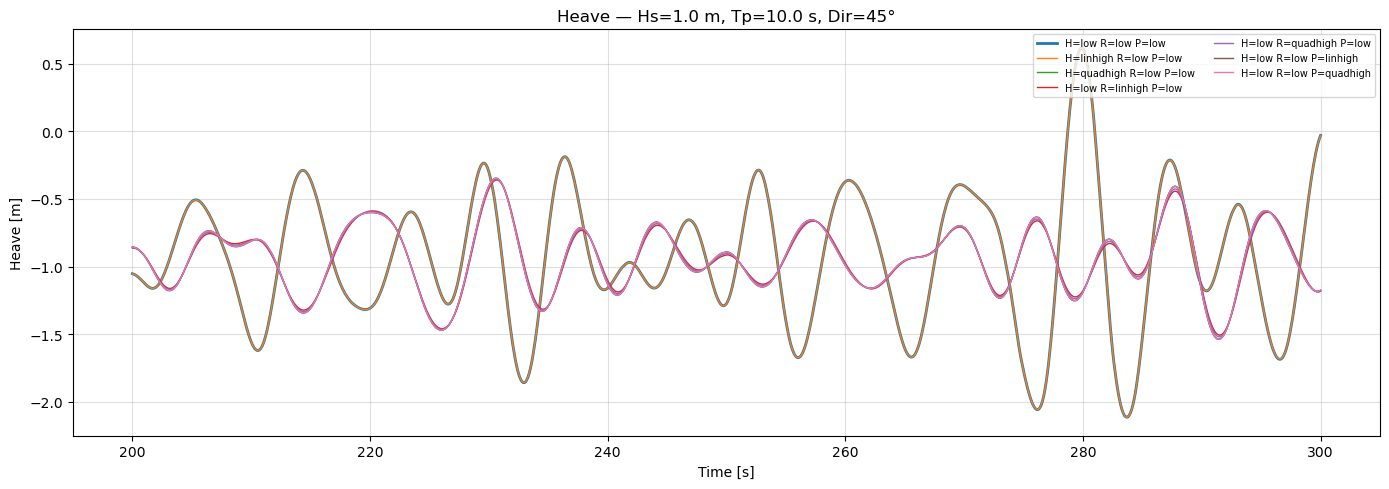

Saved: ts_heave_Hs1.0_Tp10.0_dir45.png


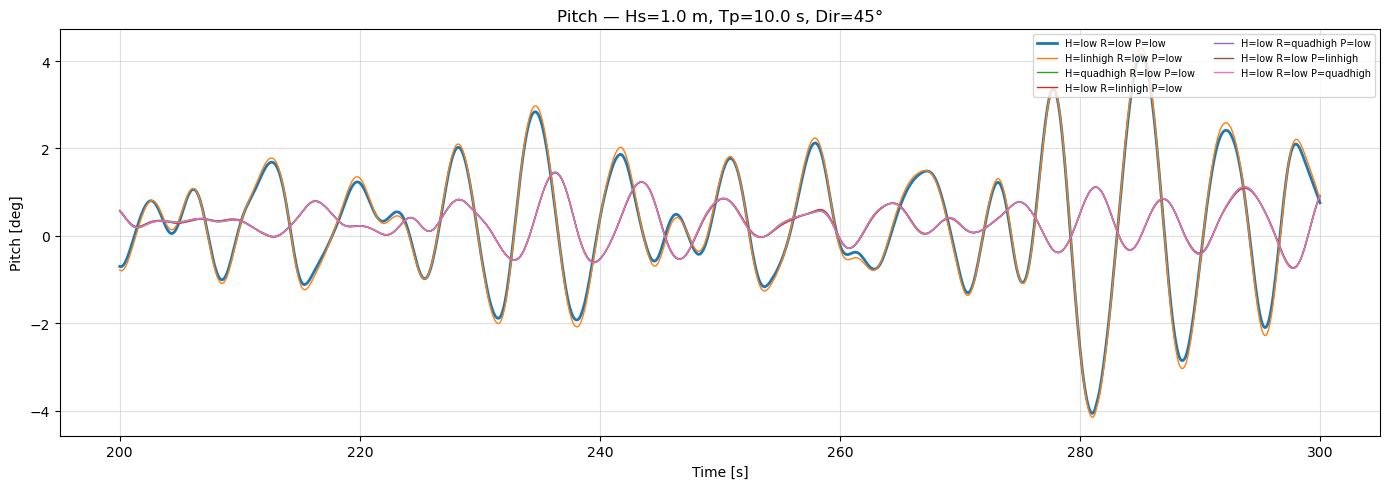

Saved: ts_pitch_Hs1.0_Tp10.0_dir45.png


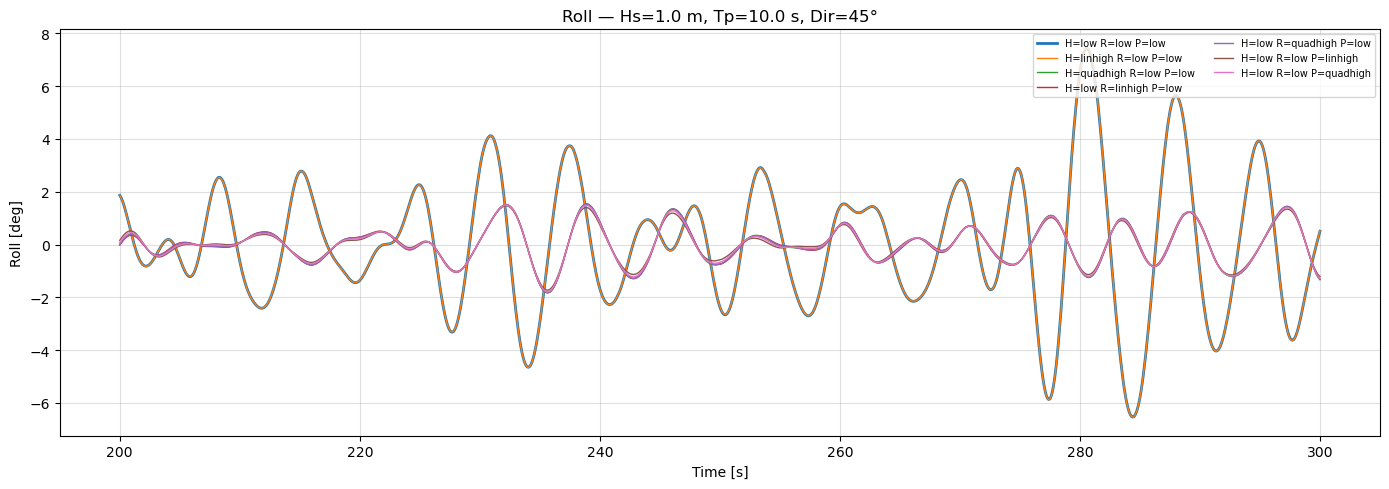

Saved: ts_roll_Hs1.0_Tp10.0_dir45.png


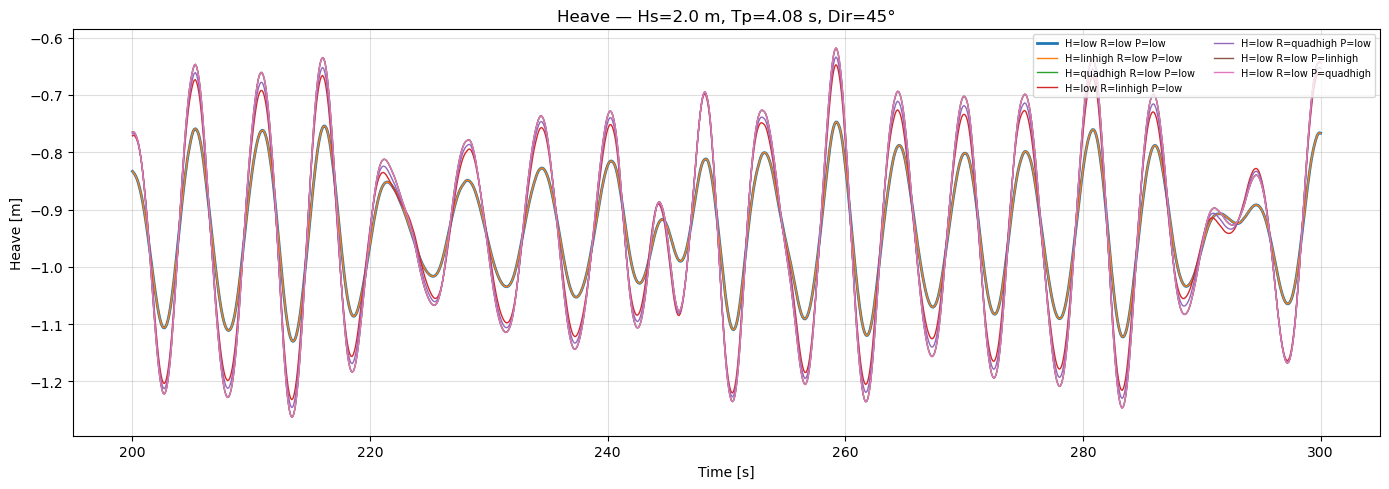

Saved: ts_heave_Hs2.0_Tp4.08_dir45.png


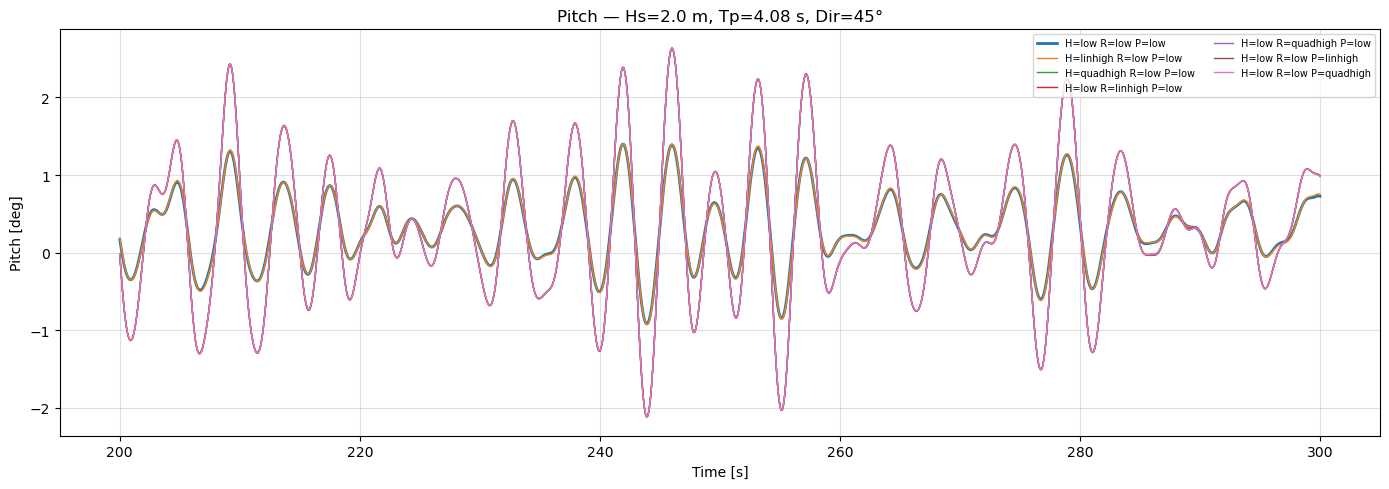

Saved: ts_pitch_Hs2.0_Tp4.08_dir45.png


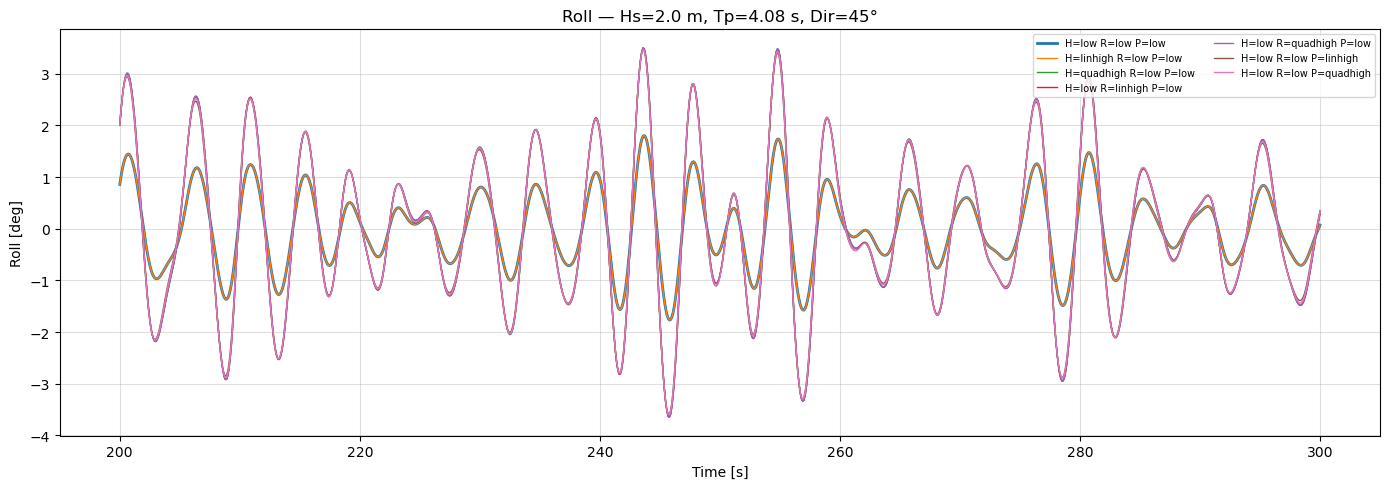

Saved: ts_roll_Hs2.0_Tp4.08_dir45.png


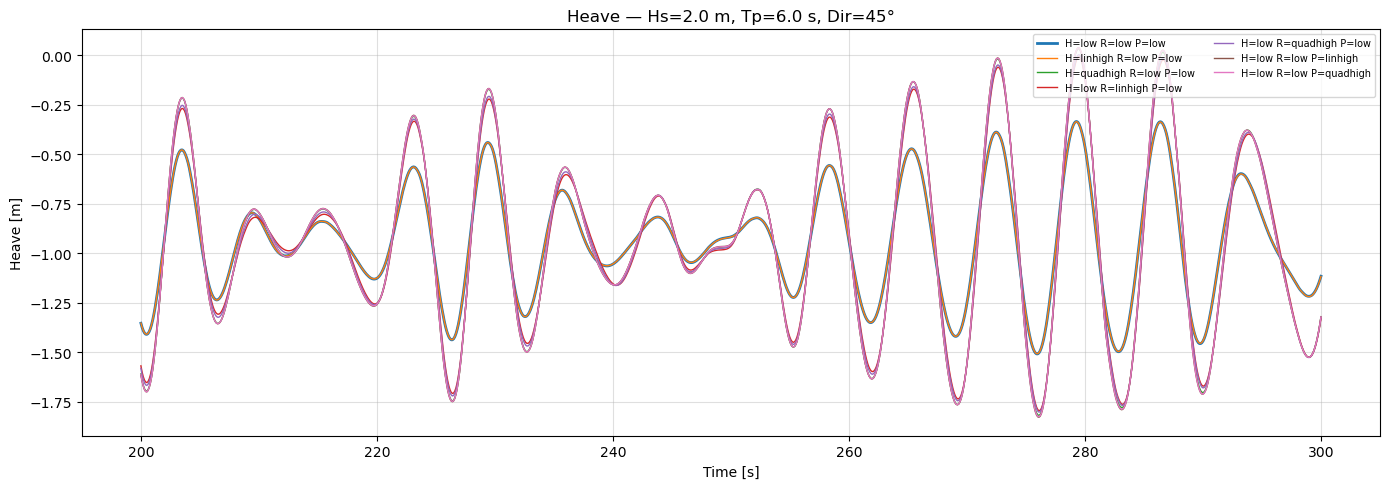

Saved: ts_heave_Hs2.0_Tp6.0_dir45.png


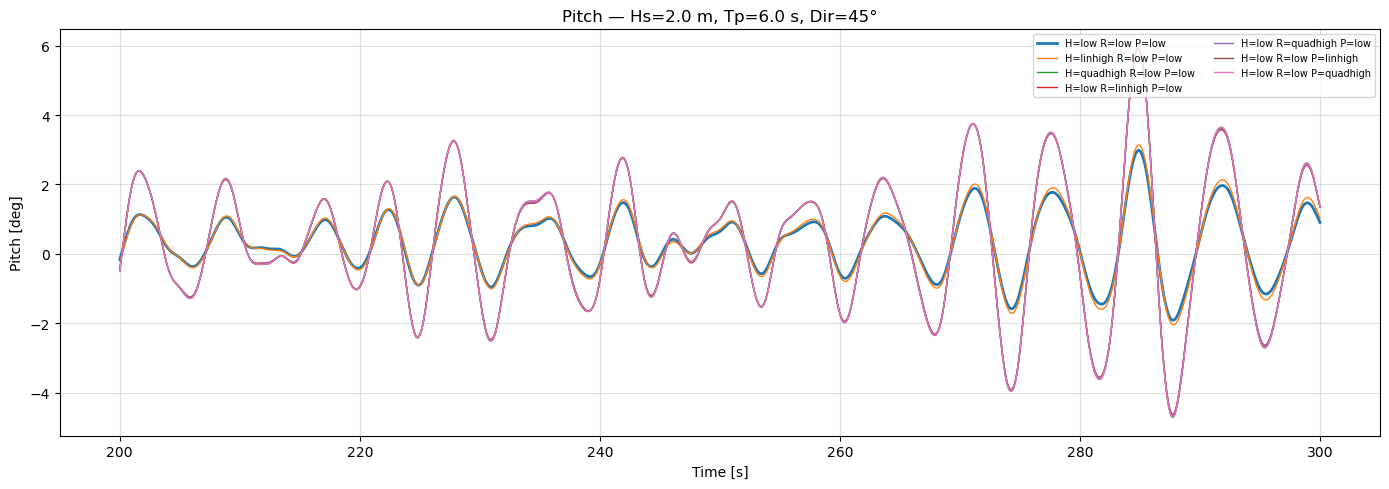

Saved: ts_pitch_Hs2.0_Tp6.0_dir45.png


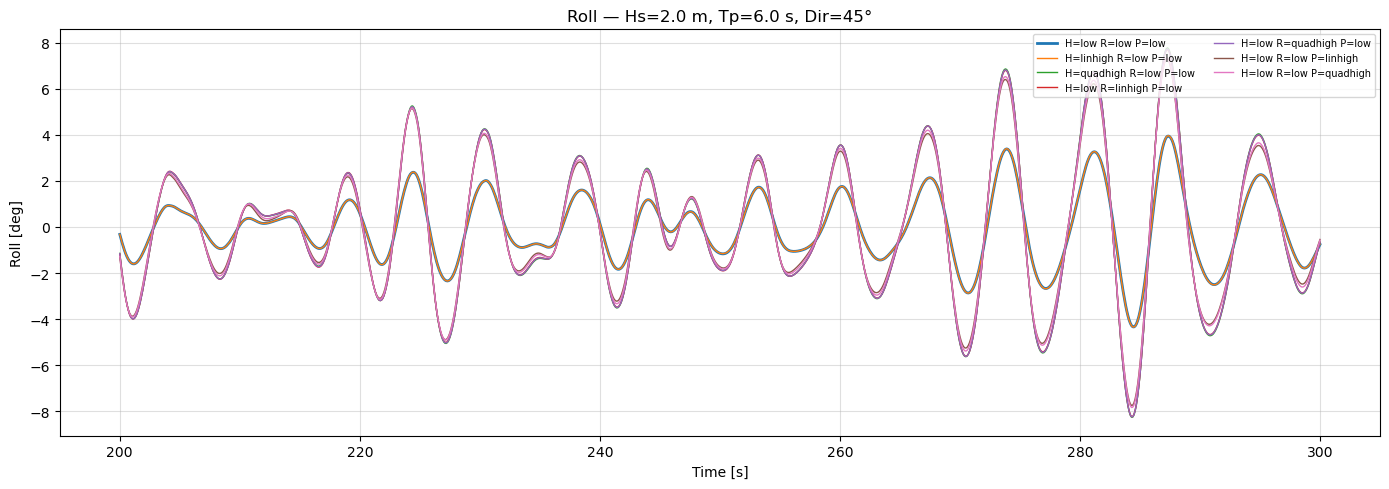

Saved: ts_roll_Hs2.0_Tp6.0_dir45.png


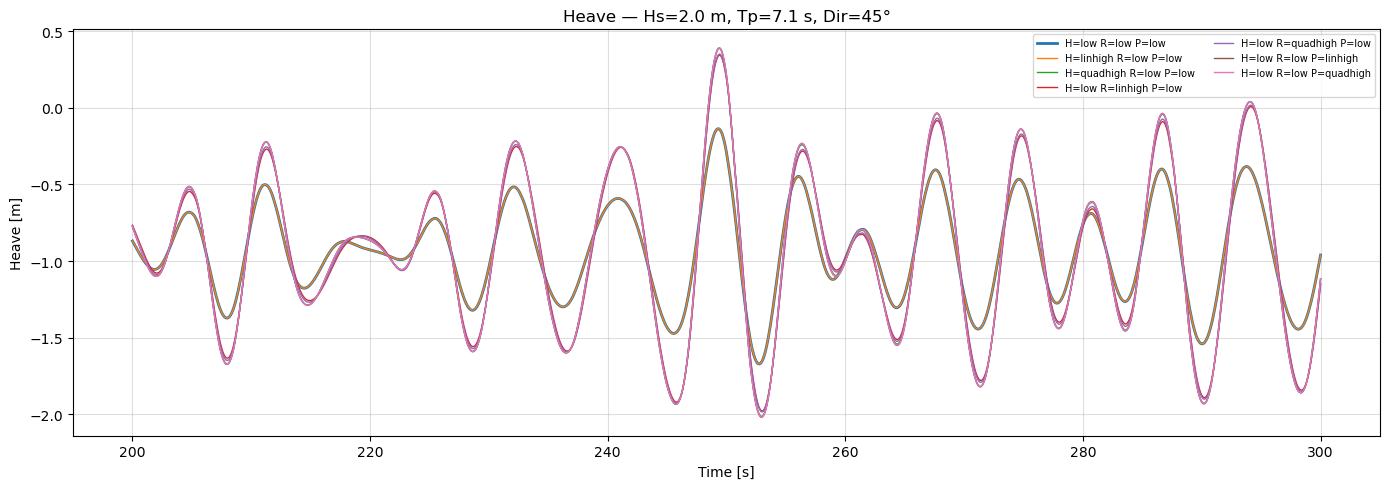

Saved: ts_heave_Hs2.0_Tp7.1_dir45.png


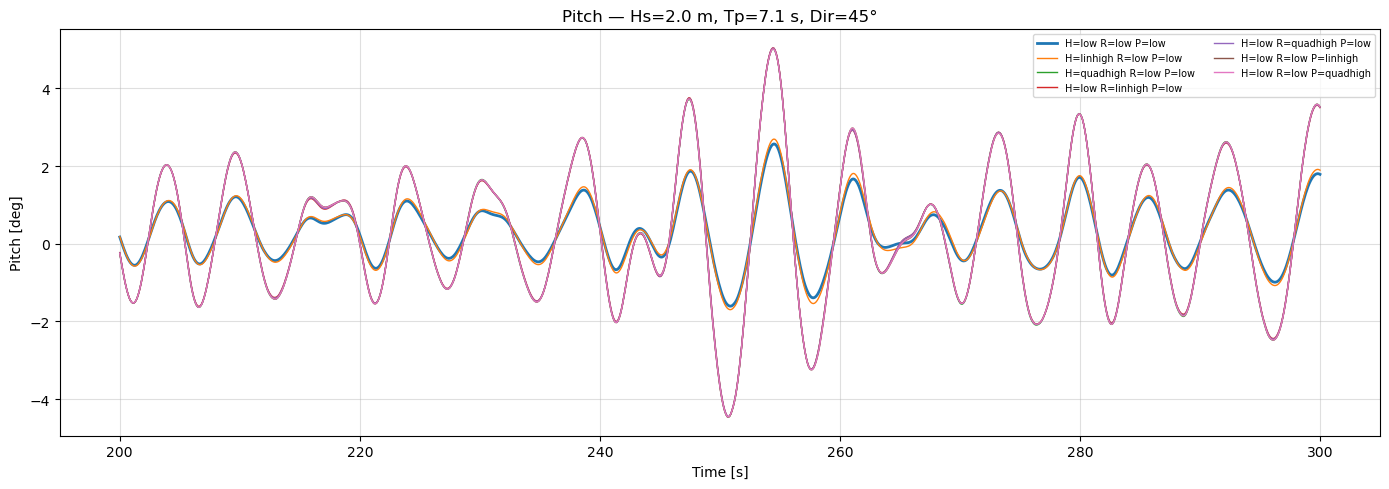

Saved: ts_pitch_Hs2.0_Tp7.1_dir45.png


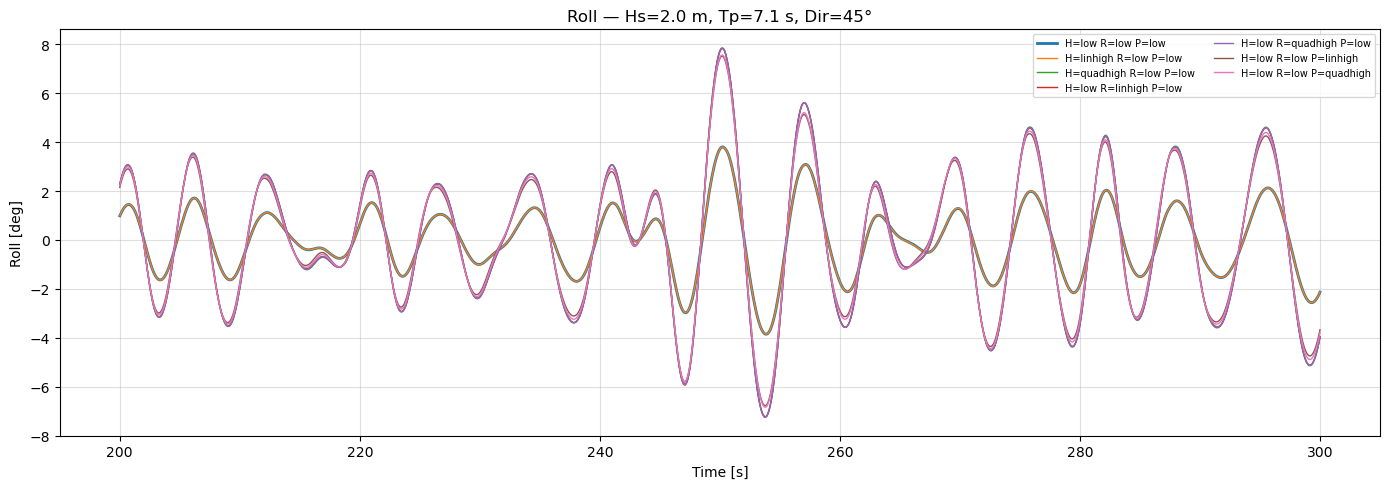

Saved: ts_roll_Hs2.0_Tp7.1_dir45.png


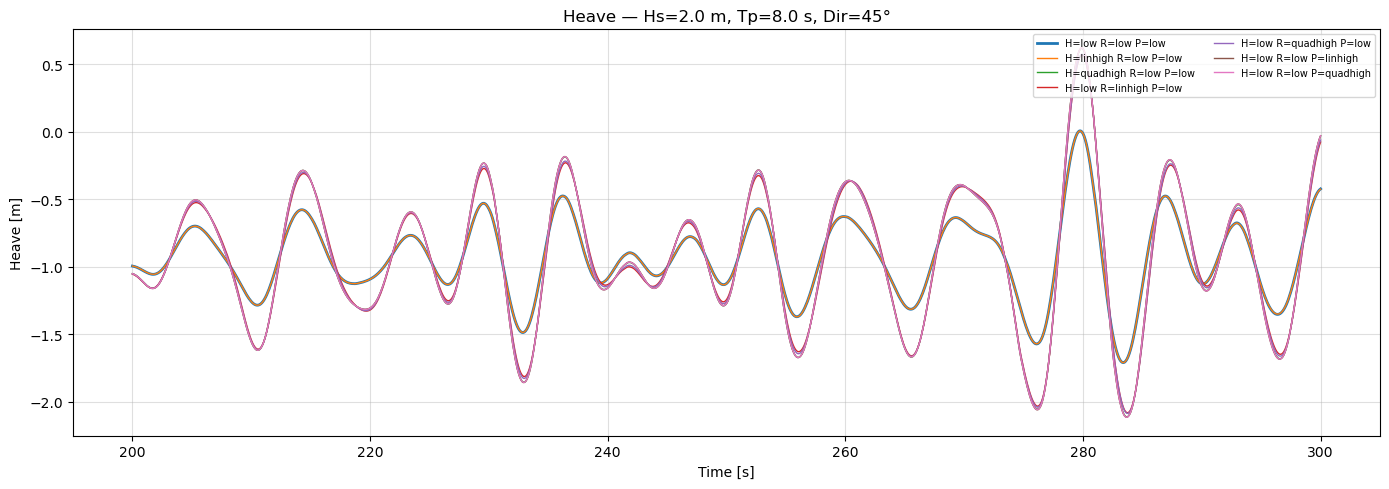

Saved: ts_heave_Hs2.0_Tp8.0_dir45.png


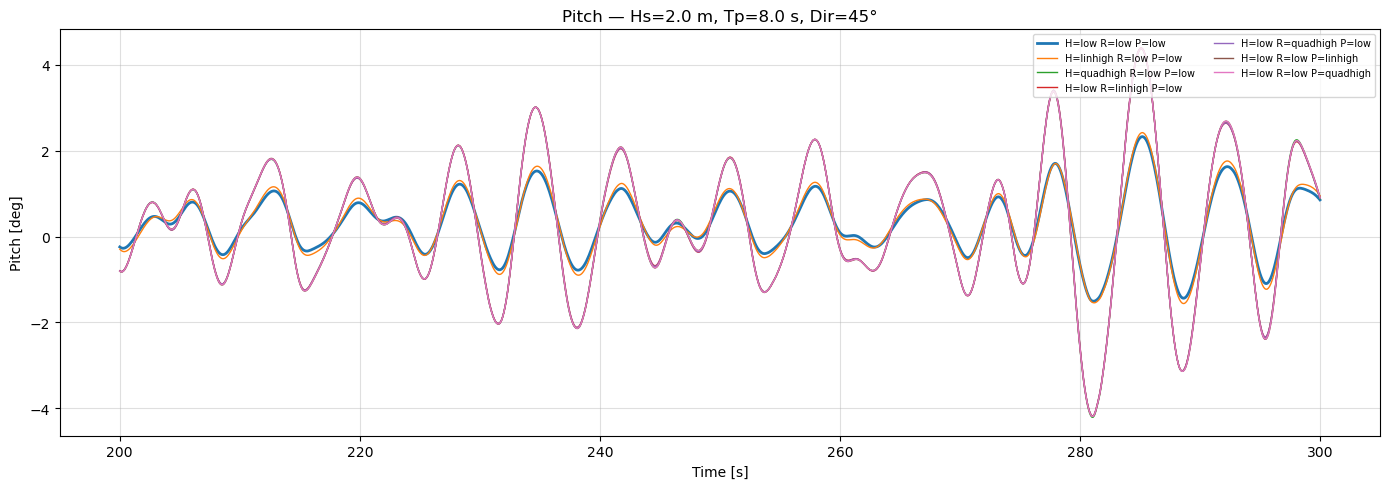

Saved: ts_pitch_Hs2.0_Tp8.0_dir45.png


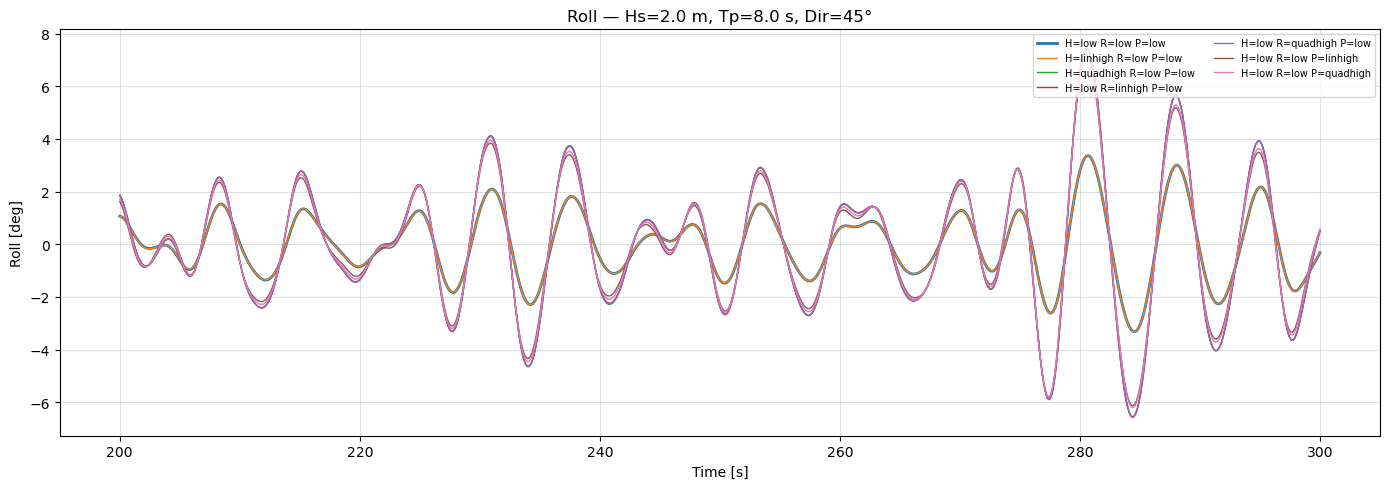

Saved: ts_roll_Hs2.0_Tp8.0_dir45.png


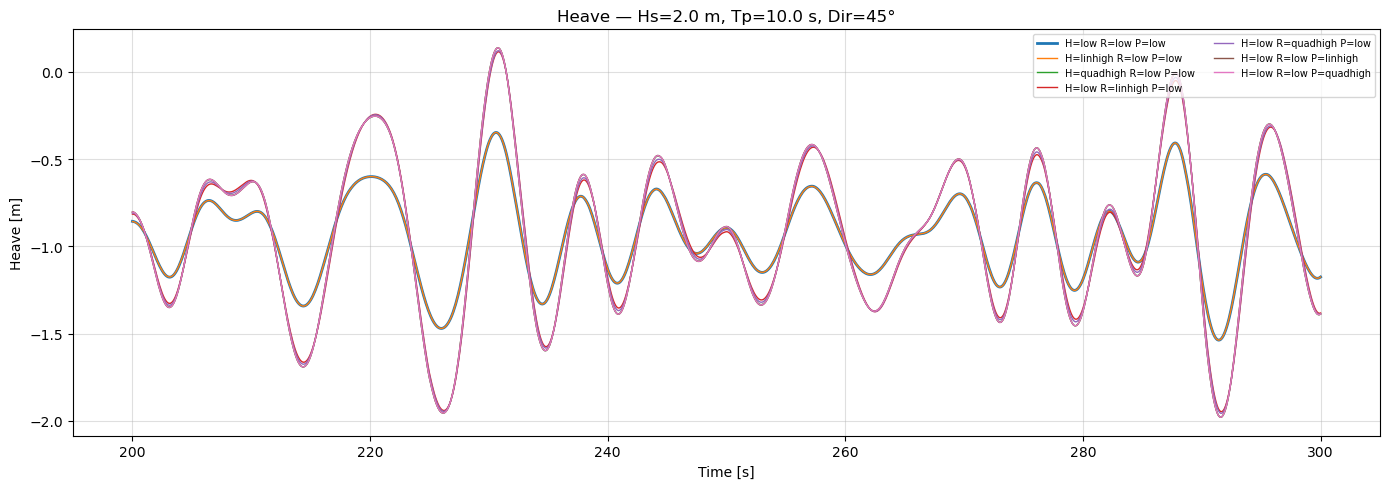

Saved: ts_heave_Hs2.0_Tp10.0_dir45.png


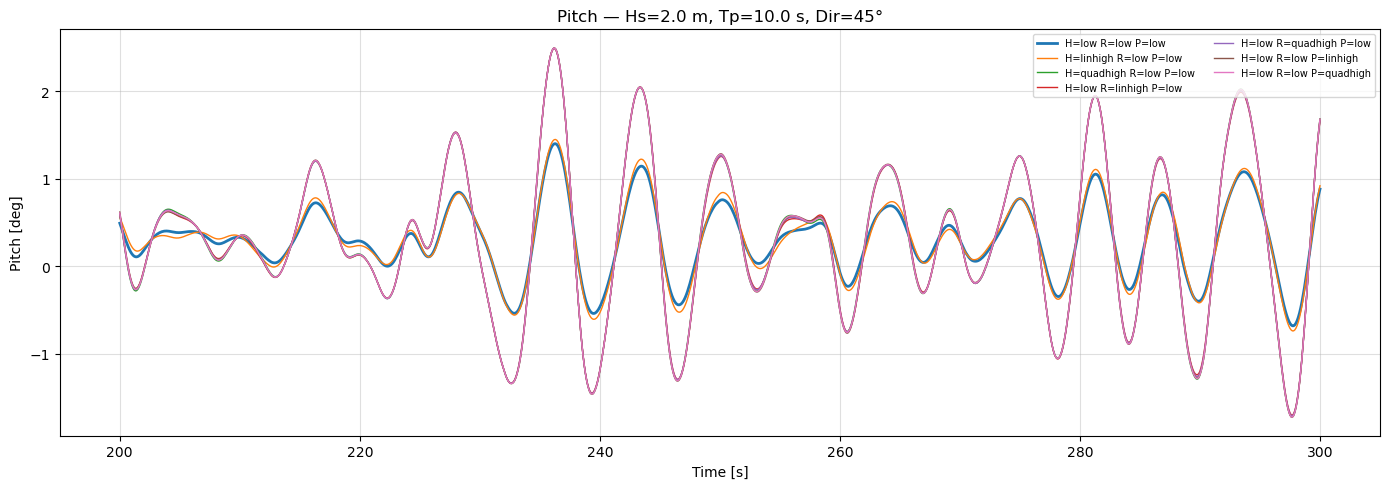

Saved: ts_pitch_Hs2.0_Tp10.0_dir45.png


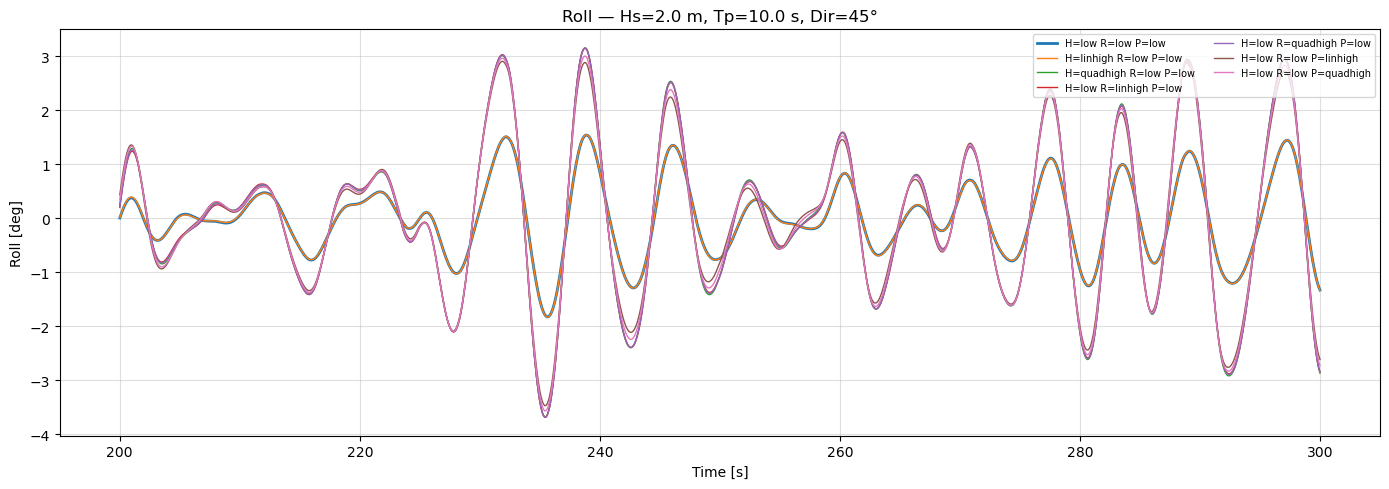

Saved: ts_roll_Hs2.0_Tp10.0_dir45.png


In [9]:
# ============================================================
# 9. Time series plots (200–300 s) per seastate + direction
#    All damping cases overlaid
# ============================================================
mask_t = (time >= T_PLOT_START) & (time <= T_PLOT_END)
t_plot = time[mask_t]

dof_info = {
    'heave': {'ts_col': '_heave_ts', 'label': 'Heave [m]'},
    'pitch': {'ts_col': '_pitch_ts', 'label': 'Pitch [deg]'},
    'roll':  {'ts_col': '_roll_ts',  'label': 'Roll [deg]'},
}

# Damping case label map (for legend)
def damp_label(row):
    return f"H={row['Damp_Heave']} R={row['Damp_Roll']} P={row['Damp_Pitch']}"

groups = results.groupby(['Hs', 'Tp', 'Direction'])

for (hs, tp, direction), group in groups:
    for dof, info in dof_info.items():
        fig, ax = plt.subplots(figsize=(14, 5))

        for _, row in group.iterrows():
            ts = row[info['ts_col']]
            label = damp_label(row)
            lw = 2.0 if (row['Damp_Heave'] == 'low' and row['Damp_Roll'] == 'low' and row['Damp_Pitch'] == 'low') else 1.0
            ax.plot(t_plot, ts[mask_t], label=label, linewidth=lw)

        ax.set_xlabel('Time [s]')
        ax.set_ylabel(info['label'])
        ax.set_title(f'{dof.capitalize()} — Hs={hs} m, Tp={tp} s, Dir={int(direction)}°')
        ax.legend(fontsize=7, ncol=2, loc='upper right')
        ax.grid(True, alpha=0.4)
        plt.tight_layout()

        fname = PLOTS_DIR / f'ts_{dof}_Hs{hs}_Tp{tp}_dir{int(direction)}.png'
        plt.savefig(fname, dpi=150)
        plt.show()
        plt.close()
        print(f'Saved: {fname.name}')

In [15]:
# # ============================================================
# # 9B. Time series — subplots per damping case
# #     One subplot per case, all three DOFs overlaid
# # ============================================================
# mask_t = (time >= T_PLOT_START) & (time <= T_PLOT_END)
# t_plot = time[mask_t]

# dof_plot_info = {
#     '_heave_ts': {'label': 'Heave [m]',   'color': 'steelblue'},
#     '_pitch_ts': {'label': 'Pitch [deg]', 'color': 'darkorange'},
#     '_roll_ts':  {'label': 'Roll [deg]',  'color': 'seagreen'},
# }

# def damp_label(row):
#     return f"H={row['Damp_Heave']} R={row['Damp_Roll']} P={row['Damp_Pitch']}"

# for (hs, tp, direction), group in results.groupby(['Hs', 'Tp', 'Direction']):
#     n_cases = len(group)
#     fig, axes = plt.subplots(n_cases, 1, figsize=(14, 3 * n_cases), sharex=True)
#     fig.suptitle(f'Time series per damping case — Hs={hs} m, Tp={tp} s, Dir={int(direction)}°', fontsize=13)

#     for ax, (_, row) in zip(axes, group.iterrows()):
#         is_ref = (row['Damp_Heave'] == 'low' and row['Damp_Roll'] == 'low' and row['Damp_Pitch'] == 'low')
#         label  = damp_label(row)

#         for ts_col, info in dof_plot_info.items():
#             ax.plot(t_plot, row[ts_col][mask_t],
#                     color=info['color'], linewidth=1.5, label=info['label'])

#         bg_color = '#fffbe6' if is_ref else 'white'
#         ax.set_facecolor(bg_color)
#         ax.set_ylabel('Response')
#         ax.set_title(f'{"★ REFERENCE — " if is_ref else ""}{label}', fontsize=9,
#                      fontweight='bold' if is_ref else 'normal')
#         ax.grid(True, alpha=0.4)
#         ax.legend(fontsize=8, loc='upper right', ncol=3)

#     axes[-1].set_xlabel('Time [s]')
#     plt.tight_layout()
#     fname = PLOTS_DIR / f'ts_subplots_Hs{hs}_Tp{tp}_dir{int(direction)}.png'
#     plt.savefig(fname, dpi=150, bbox_inches='tight')
#     plt.show()
#     plt.close()
#     print(f'Saved: {fname.name}')

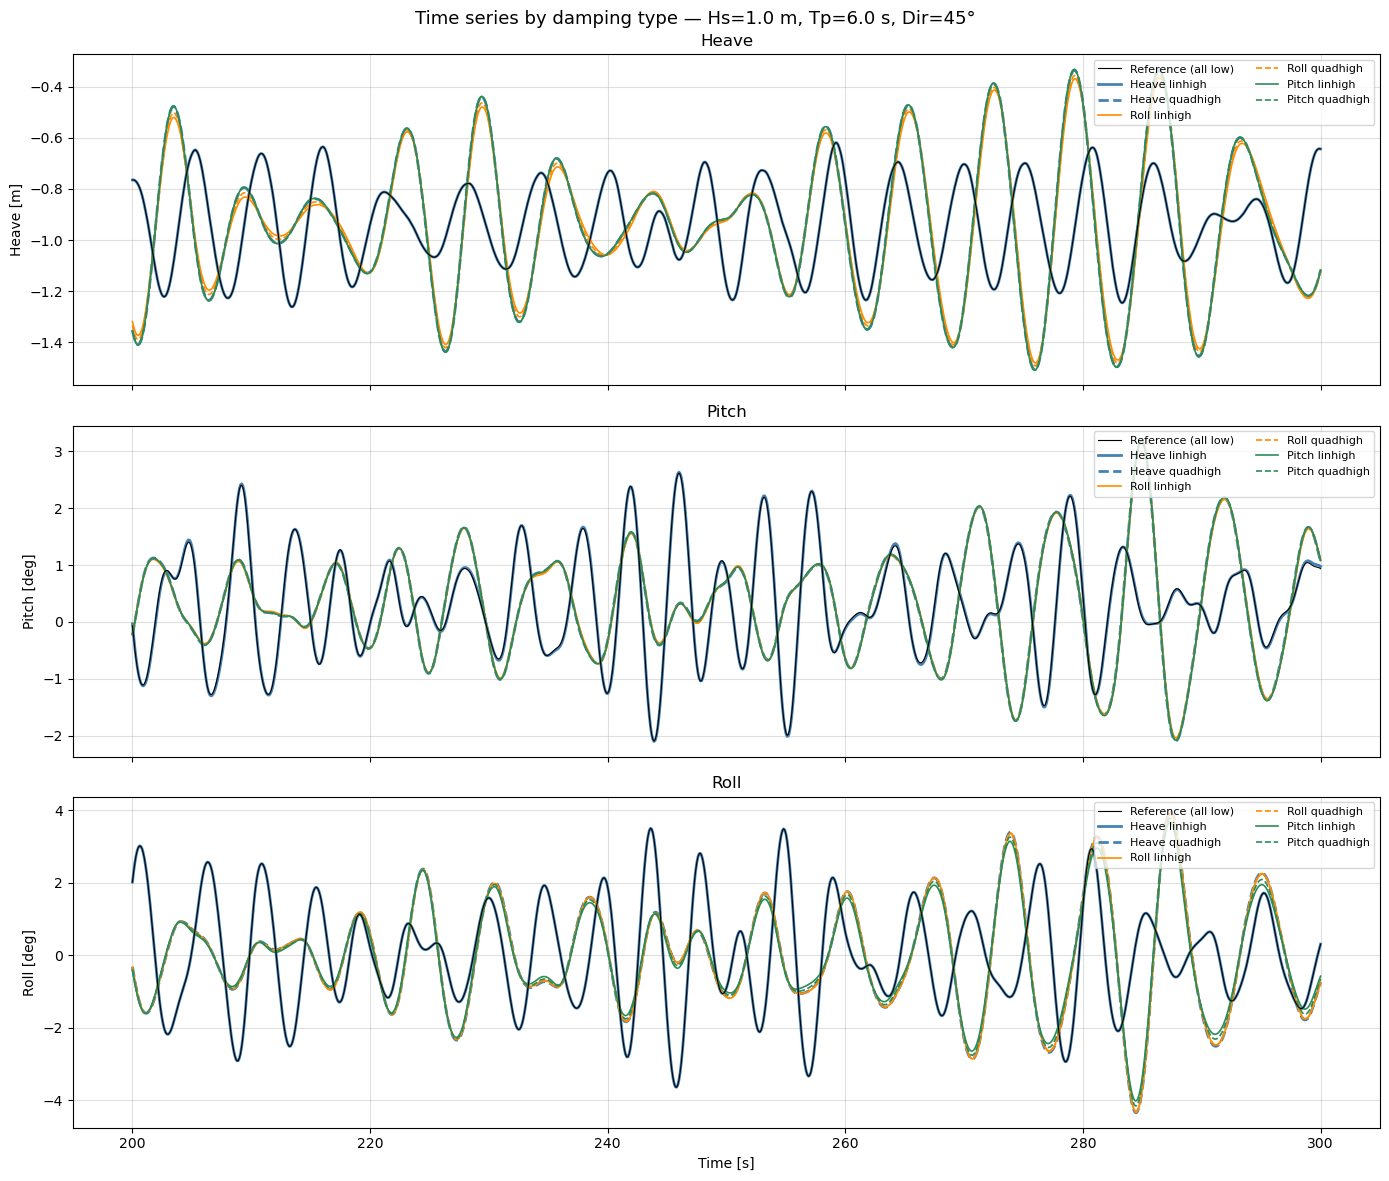

Saved: ts_bydof_Hs1.0_Tp6.0_dir45.png


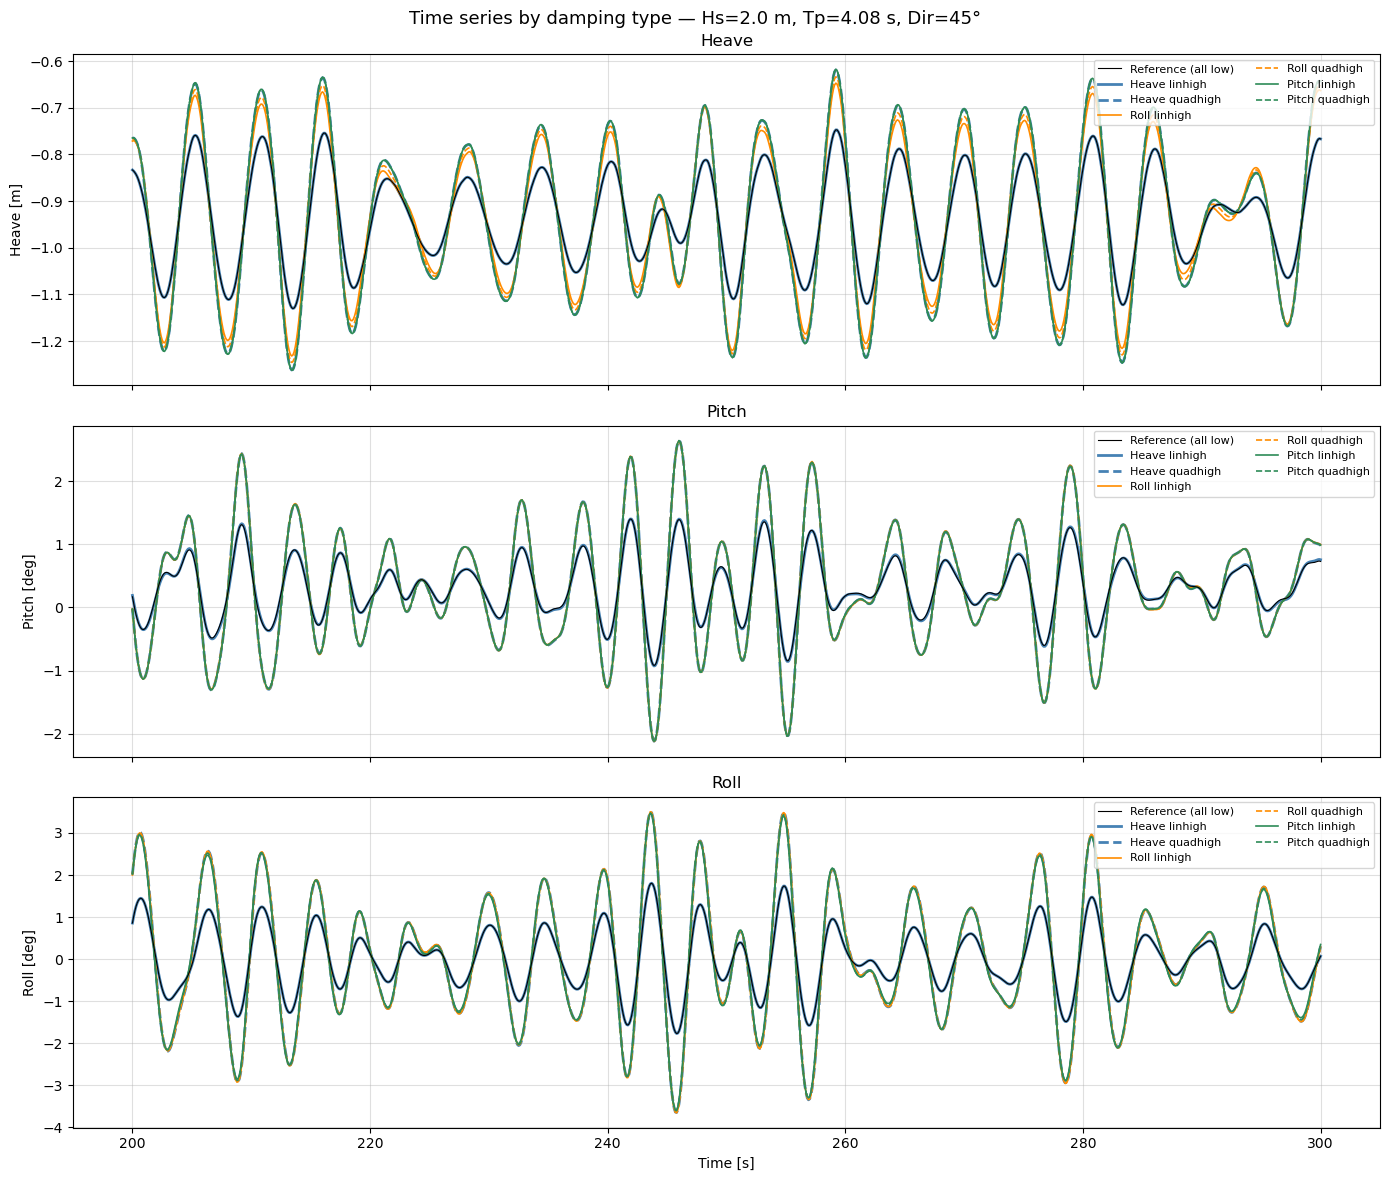

Saved: ts_bydof_Hs2.0_Tp4.08_dir45.png


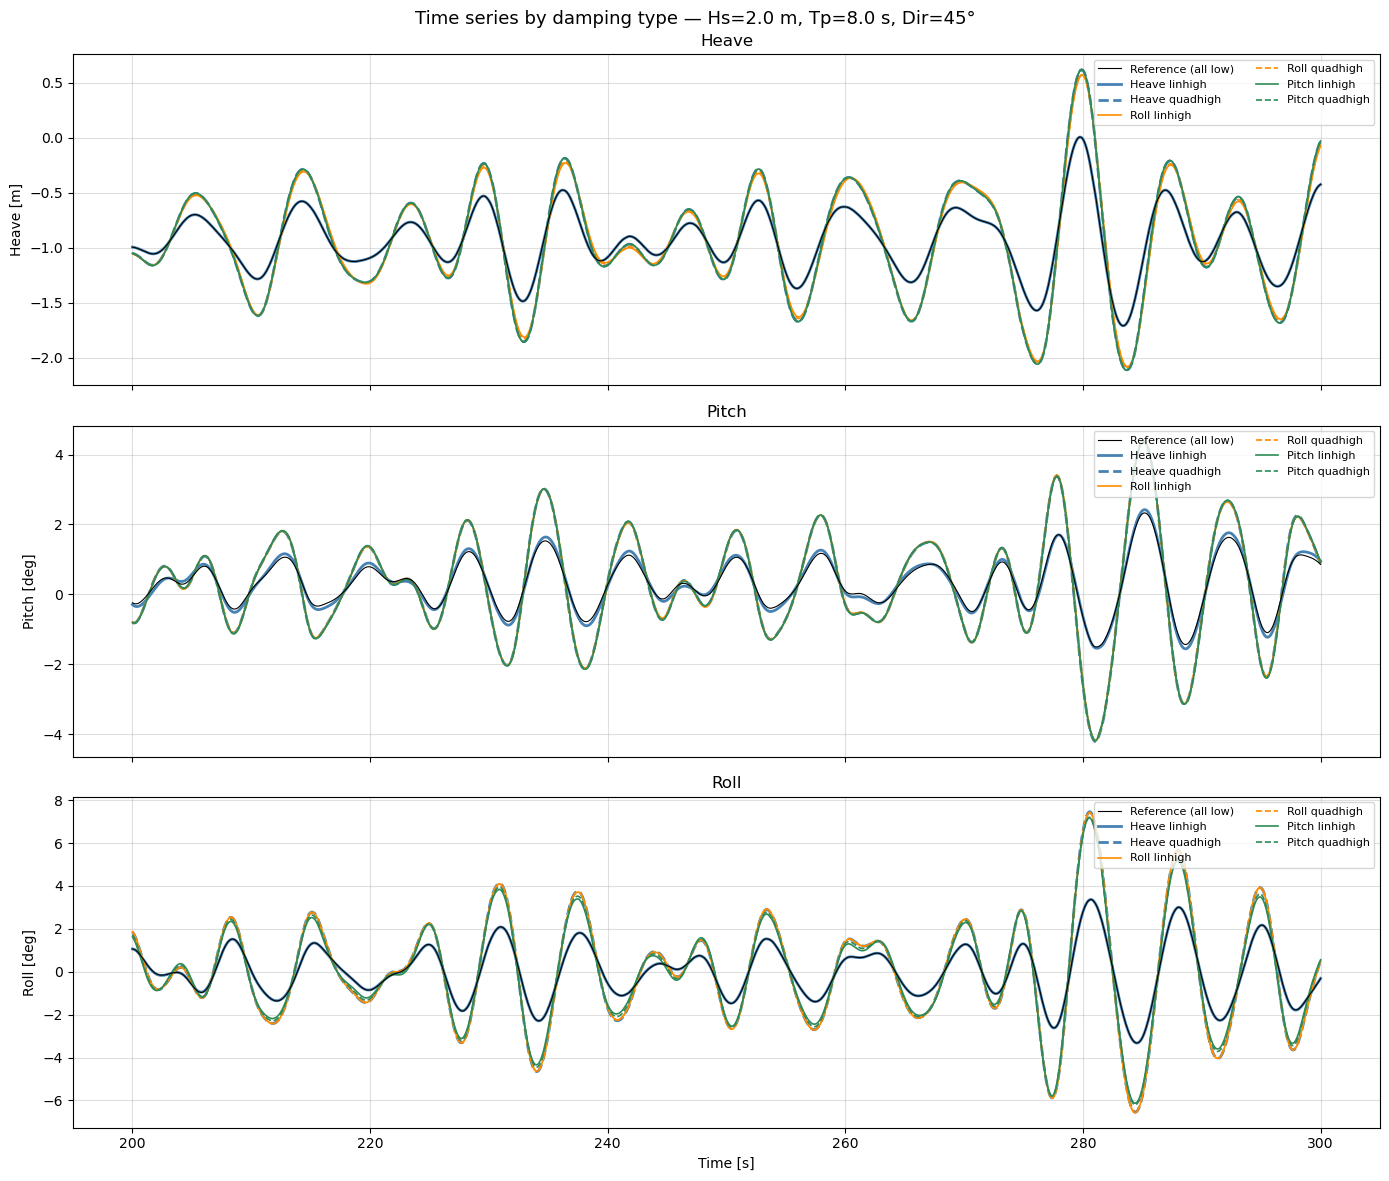

Saved: ts_bydof_Hs2.0_Tp8.0_dir45.png


In [18]:
# ============================================================
# 9C. Time series — color per varied DOF, linestyle = lin/quad
#     Selected seastates only
#     Color = which DOF is varied, linestyle = lin/quad
#     Reference = black thin, Heave = thicker
# ============================================================

dof_color_map = {
    'Heave_linhigh':  ('steelblue',  '-',  'Heave linhigh',  2.0),
    'Heave_quadhigh': ('steelblue',  '--', 'Heave quadhigh', 2.0),
    'Roll_linhigh':   ('darkorange', '-',  'Roll linhigh',   1.2),
    'Roll_quadhigh':  ('darkorange', '--', 'Roll quadhigh',  1.2),
    'Pitch_linhigh':  ('seagreen',   '-',  'Pitch linhigh',  1.2),
    'Pitch_quadhigh': ('seagreen',   '--', 'Pitch quadhigh', 1.2),
    'Reference':      ('black',      '-',  'Reference (all low)', 0.8),
}

def case_type(row):
    if row['Damp_Heave'] == 'linhigh':  return 'Heave_linhigh'
    if row['Damp_Heave'] == 'quadhigh': return 'Heave_quadhigh'
    if row['Damp_Roll']  == 'linhigh':  return 'Roll_linhigh'
    if row['Damp_Roll']  == 'quadhigh': return 'Roll_quadhigh'
    if row['Damp_Pitch'] == 'linhigh':  return 'Pitch_linhigh'
    if row['Damp_Pitch'] == 'quadhigh': return 'Pitch_quadhigh'
    return 'Reference'

dof_ts_info = {
    'heave': {'ts_col': '_heave_ts', 'ylabel': 'Heave [m]'},
    'pitch': {'ts_col': '_pitch_ts', 'ylabel': 'Pitch [deg]'},
    'roll':  {'ts_col': '_roll_ts',  'ylabel': 'Roll [deg]'},
}

# Selected seastates only
selected_seastates = [
    (1, 6.0),
    (2, 4.08),
    (2, 8.0),
]

for (hs, tp, direction), group in results.groupby(['Hs', 'Tp', 'Direction']):
    if (hs, tp) not in selected_seastates:
        continue

    fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
    fig.suptitle(f'Time series by damping type — Hs={hs} m, Tp={tp} s, Dir={int(direction)}°', fontsize=13)

    for ax, (dof, info) in zip(axes, dof_ts_info.items()):
        for _, row in group.iterrows():
            ctype                  = case_type(row)
            color, ls, label, lw  = dof_color_map[ctype]
            zorder                 = 3 if ctype == 'Reference' else 2

            ax.plot(t_plot, row[info['ts_col']][mask_t],
                    color=color, linestyle=ls, linewidth=lw,
                    label=label, zorder=zorder)

        ax.set_ylabel(info['ylabel'])
        ax.set_title(dof.capitalize())
        ax.grid(True, alpha=0.4)

        handles, labels = ax.get_legend_handles_labels()
        by_label = dict(zip(labels, handles))
        ax.legend(by_label.values(), by_label.keys(),
                  fontsize=8, loc='upper right', ncol=2)

    axes[-1].set_xlabel('Time [s]')
    plt.tight_layout()
    fname = PLOTS_DIR / f'ts_bydof_Hs{hs}_Tp{tp}_dir{int(direction)}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f'Saved: {fname.name}')

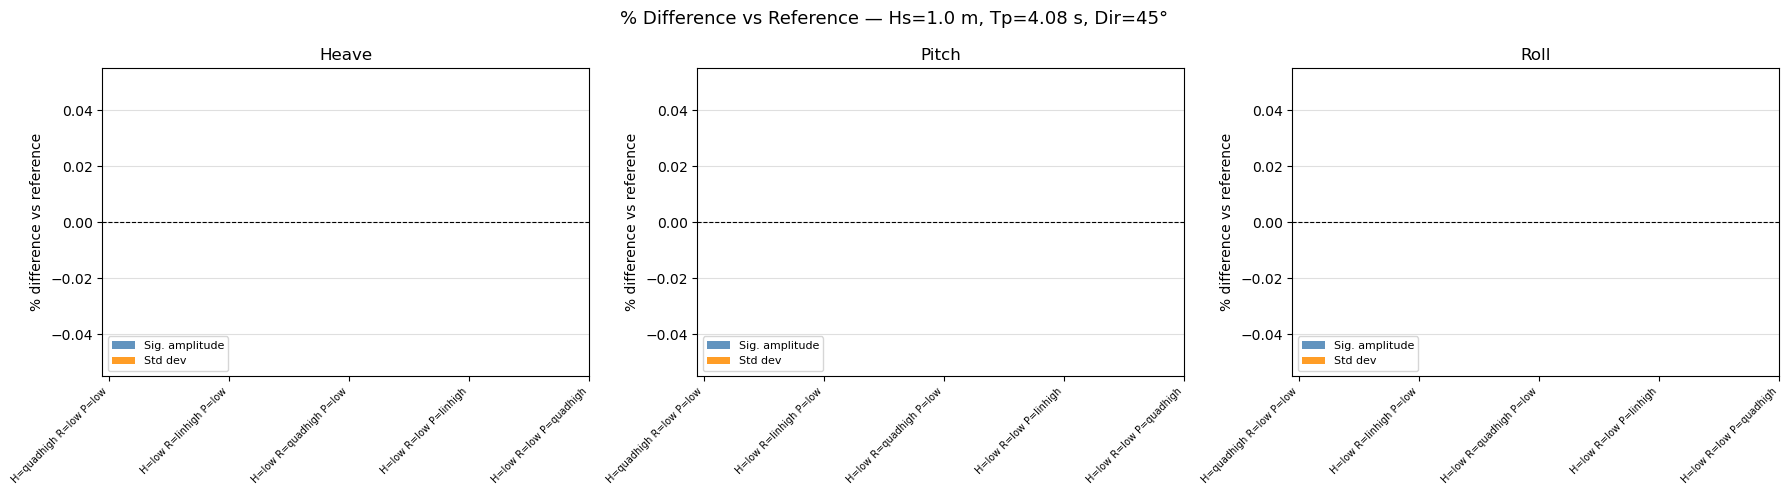

Saved: barchart_Hs1.0_Tp4.08_dir45.png


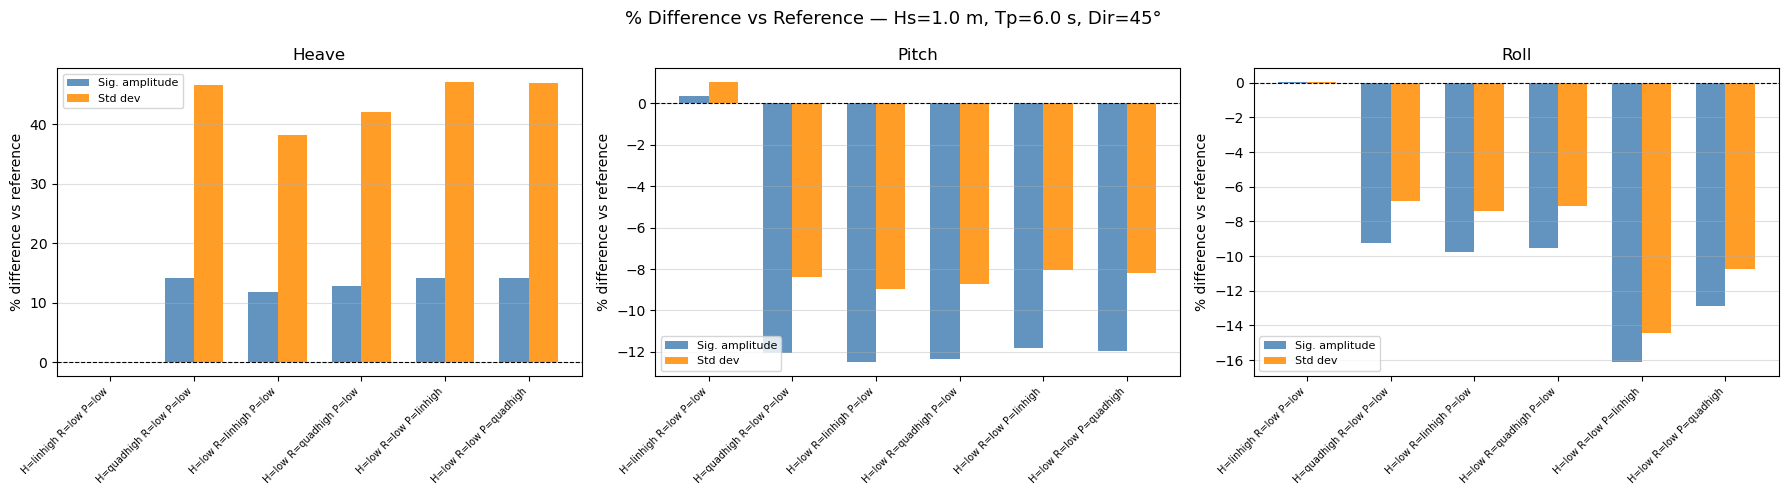

Saved: barchart_Hs1.0_Tp6.0_dir45.png


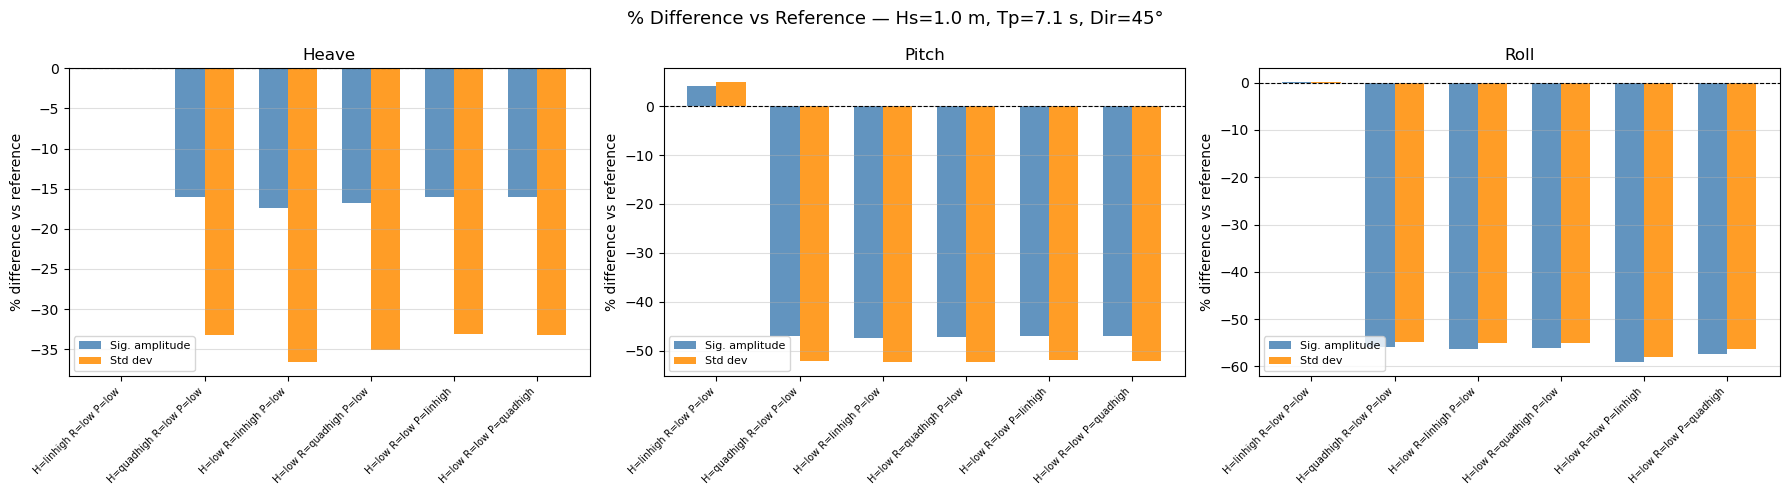

Saved: barchart_Hs1.0_Tp7.1_dir45.png


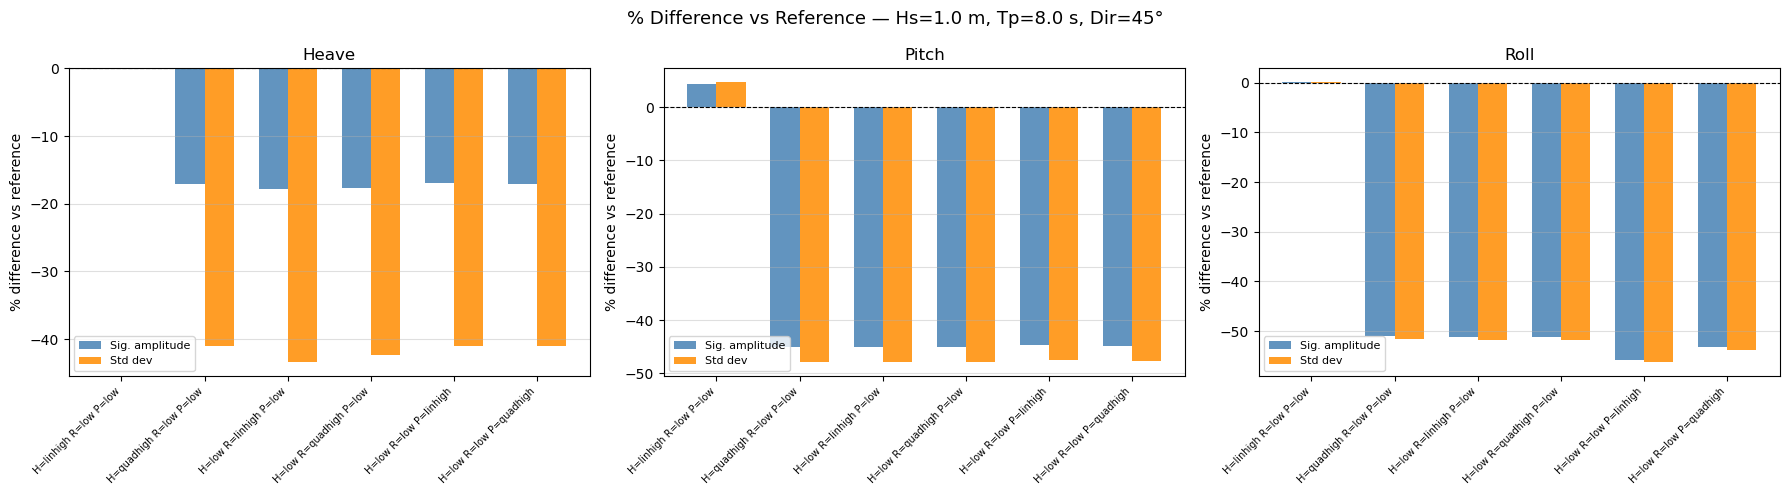

Saved: barchart_Hs1.0_Tp8.0_dir45.png


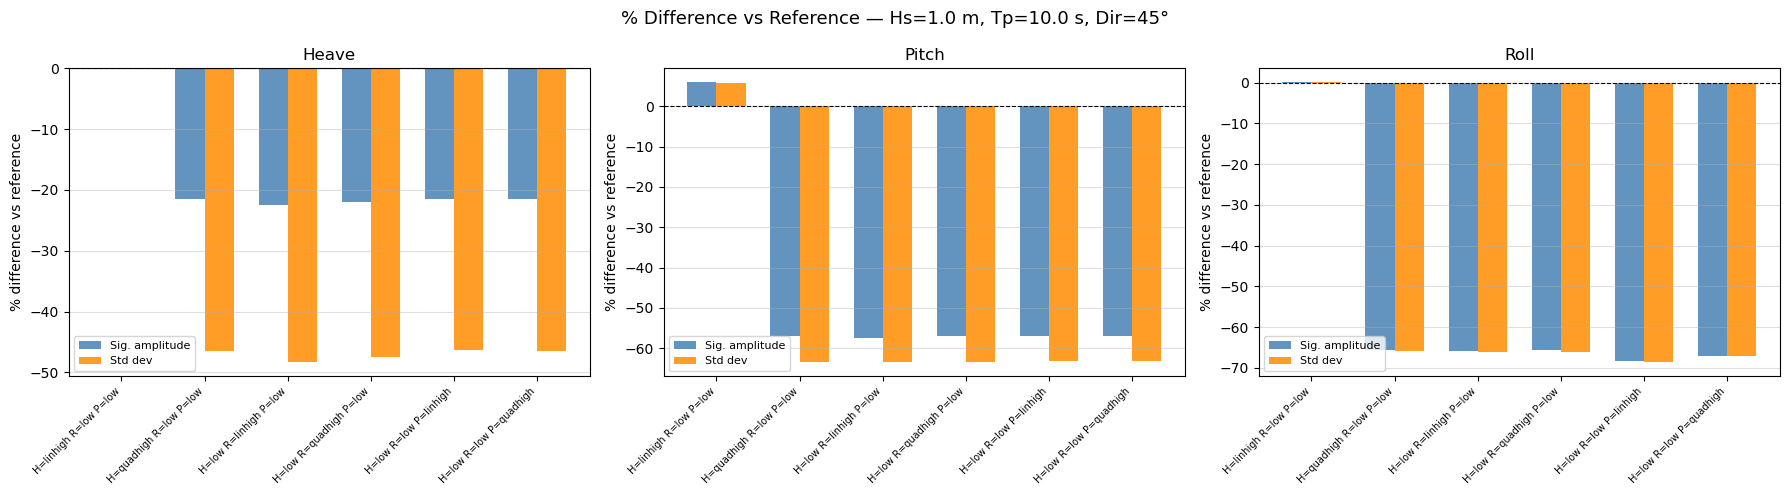

Saved: barchart_Hs1.0_Tp10.0_dir45.png


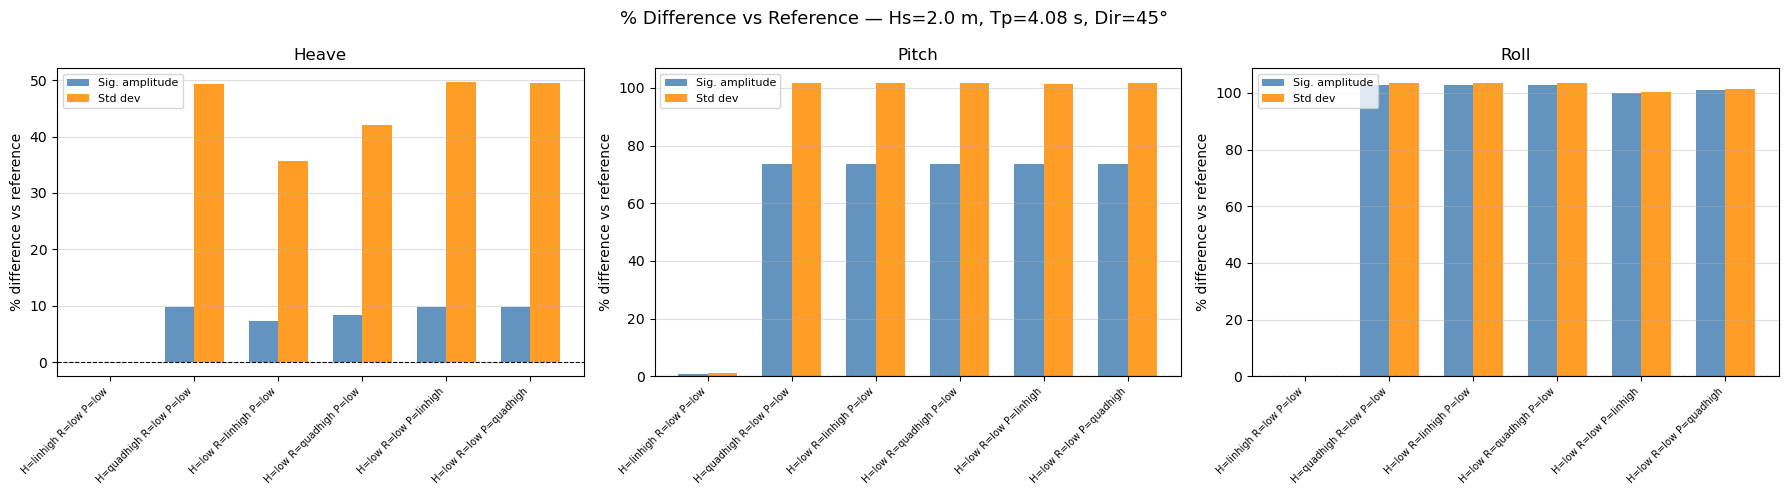

Saved: barchart_Hs2.0_Tp4.08_dir45.png


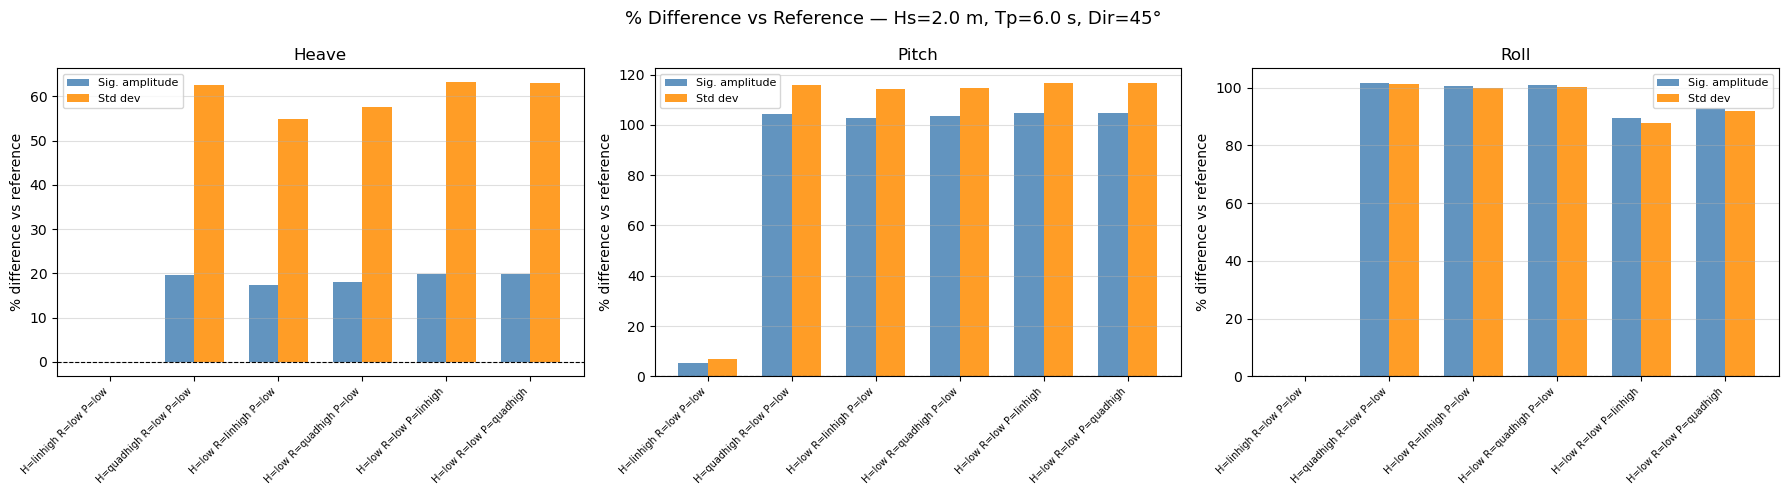

Saved: barchart_Hs2.0_Tp6.0_dir45.png


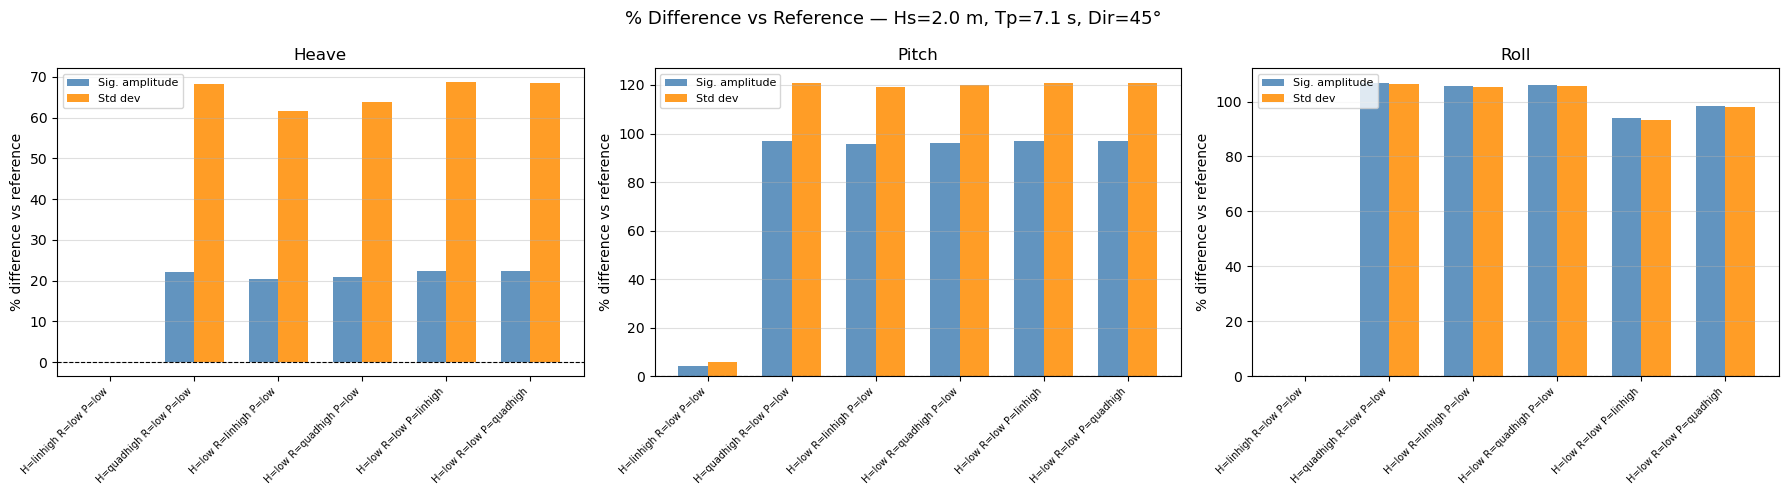

Saved: barchart_Hs2.0_Tp7.1_dir45.png


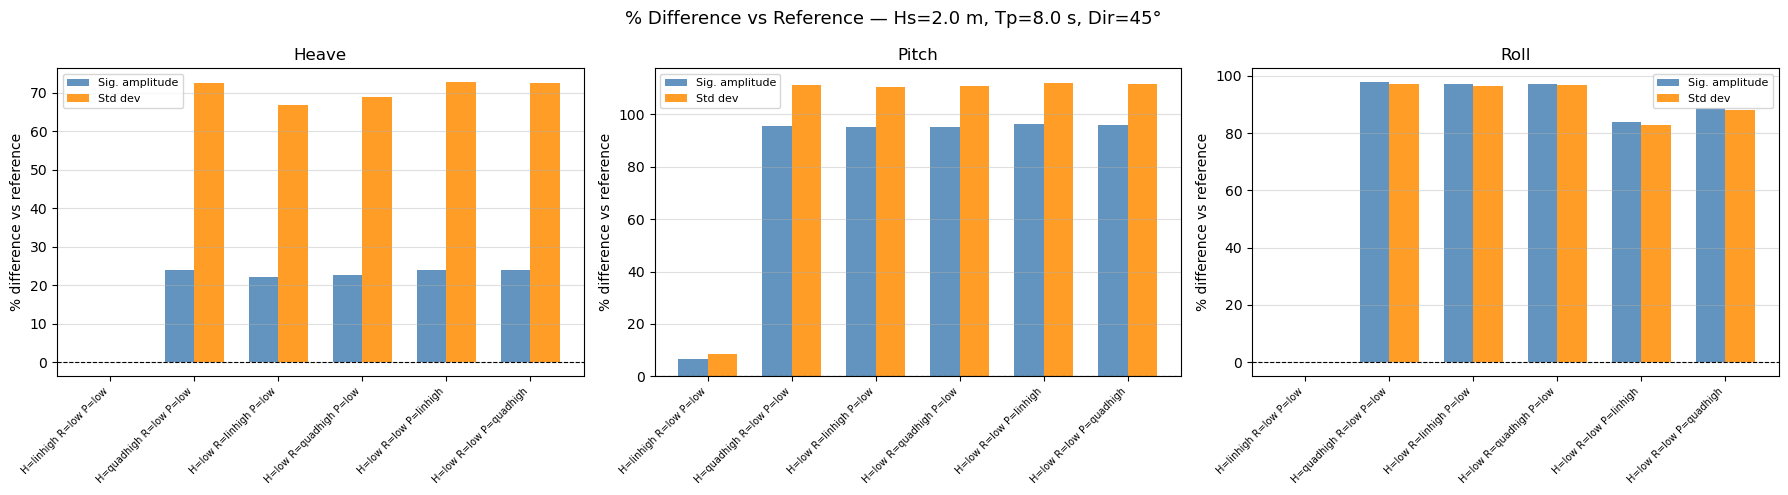

Saved: barchart_Hs2.0_Tp8.0_dir45.png


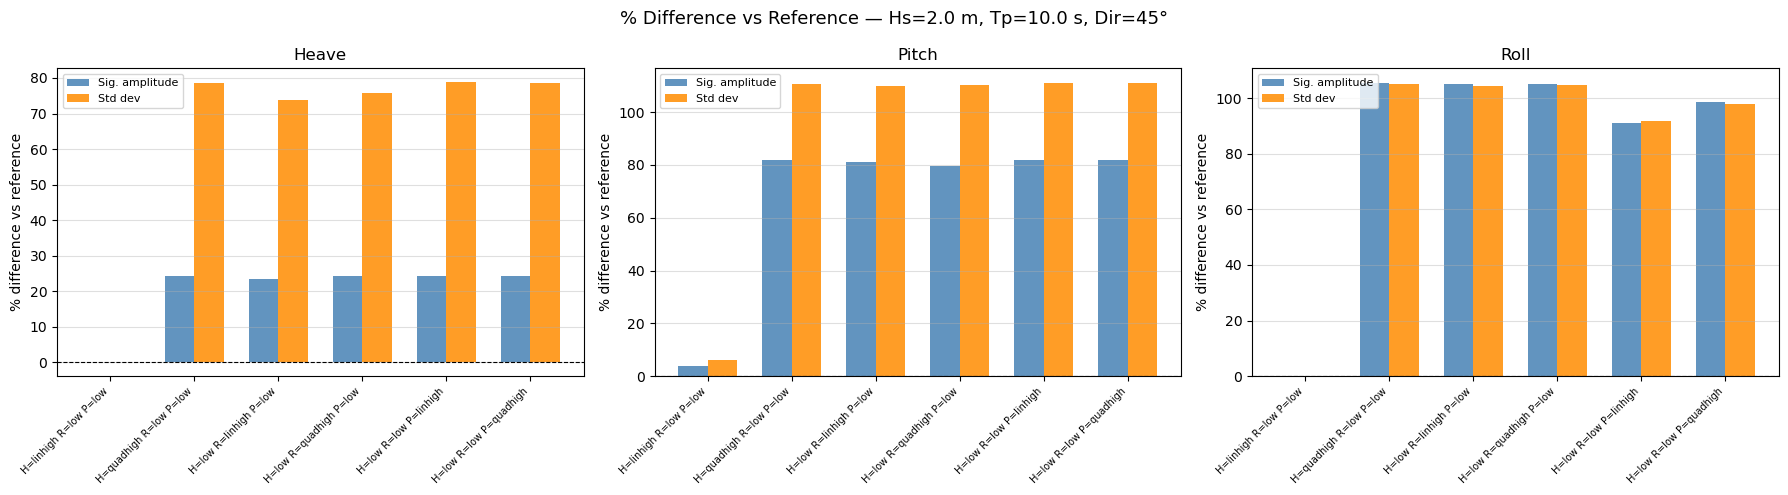

Saved: barchart_Hs2.0_Tp10.0_dir45.png


In [10]:
# ============================================================
# 10. Bar charts: % difference in sig amplitude + std
#     Per seastate, per direction, per DOF
#     (Reference case excluded — it's always 0%)
# ============================================================
non_ref = results[~is_ref].copy()
non_ref['damp_label'] = non_ref.apply(damp_label, axis=1)

pct_pairs = {
    'heave': ('heave_sig_amp_pct', 'heave_std_pct'),
    'pitch': ('pitch_sig_amp_pct', 'pitch_std_pct'),
    'roll':  ('roll_sig_amp_pct',  'roll_std_pct'),
}

for (hs, tp, direction), group in non_ref.groupby(['Hs', 'Tp', 'Direction']):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)
    fig.suptitle(f'% Difference vs Reference — Hs={hs} m, Tp={tp} s, Dir={int(direction)}°', fontsize=13)

    for ax, (dof, (sa_col, std_col)) in zip(axes, pct_pairs.items()):
        labels = group['damp_label'].values
        sa_vals  = group[sa_col].values
        std_vals = group[std_col].values

        x = np.arange(len(labels))
        width = 0.35

        ax.bar(x - width/2, sa_vals,  width, label='Sig. amplitude', color='steelblue', alpha=0.85)
        ax.bar(x + width/2, std_vals, width, label='Std dev',         color='darkorange', alpha=0.85)

        ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
        ax.set_title(dof.capitalize())
        ax.set_ylabel('% difference vs reference')
        ax.set_xticks(x)
        ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=7)
        ax.legend(fontsize=8)
        ax.grid(True, axis='y', alpha=0.4)

    plt.tight_layout()
    fname = PLOTS_DIR / f'barchart_Hs{hs}_Tp{tp}_dir{int(direction)}.png'
    plt.savefig(fname, dpi=150)
    plt.show()
    plt.close()
    print(f'Saved: {fname.name}')

In [11]:
# ============================================================
# 11. Summary: which damping parameter has most influence?
#     Average |% difference| per varied DOF across all seastates
#     NOTE: direction 45° — all DOFs included
# ============================================================
def which_dof_varied(row):
    """Determine which DOF is varied (not 'low') in this case."""
    varied = []
    if row['Damp_Heave'] != 'low': varied.append('Heave')
    if row['Damp_Roll']  != 'low': varied.append('Roll')
    if row['Damp_Pitch'] != 'low': varied.append('Pitch')
    return '+'.join(varied) if varied else 'Reference'

non_ref['Varied_DOF'] = non_ref.apply(which_dof_varied, axis=1)

non_ref_45 = non_ref[non_ref['Direction'] == 45]

# dir=45: all DOFs included (heave + pitch + roll)
summary_cols_45 = ['heave_sig_amp_pct', 'pitch_sig_amp_pct', 'roll_sig_amp_pct',
                   'heave_std_pct',     'pitch_std_pct',     'roll_std_pct']

summary_45 = non_ref_45.groupby('Varied_DOF')[summary_cols_45].apply(lambda x: x.abs().mean())
summary_45.columns = ['Δheave_sigamp%', 'Δpitch_sigamp%', 'Δroll_sigamp%',
                      'Δheave_std%',    'Δpitch_std%',    'Δroll_std%']

print('\nDirection 45° — Mean absolute % difference (all DOFs):')
print(summary_45.round(2).to_string())

# Save to Excel
with pd.ExcelWriter(OUTPUT_DIR / 'sensitivity_summary_45deg.xlsx') as writer:
    summary_45.to_excel(writer, sheet_name='Direction_45')

print(f'\nSummary saved → {OUTPUT_DIR / "sensitivity_summary_45deg.xlsx"}')


Direction 45° — Mean absolute % difference (all DOFs):
            Δheave_sigamp%  Δpitch_sigamp%  Δroll_sigamp%  Δheave_std%  Δpitch_std%  Δroll_std%
Varied_DOF                                                                                     
Heave                 9.36           36.09          38.69        27.72        43.16       38.49
Pitch                18.75           68.24          73.80        55.57        81.41       73.24
Roll                 17.98           67.83          77.16        51.91        80.97       76.74

Summary saved → C:\Users\verav\Desktop\Studie\Afstuderen\Simulaties\Sensitivity1\analysis\sensitivity_summary_45deg.xlsx


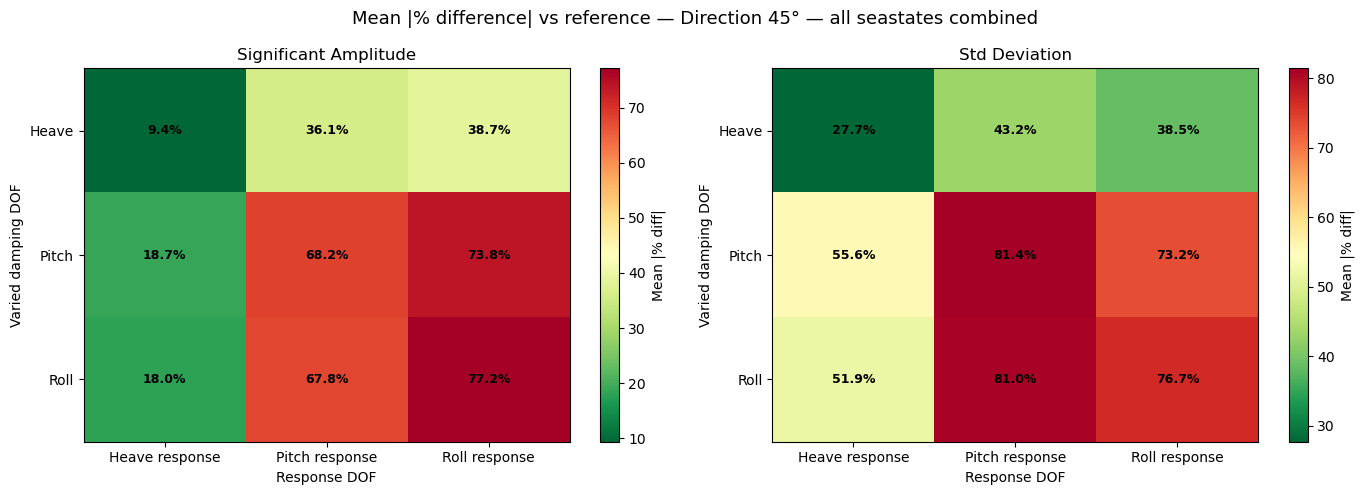

Saved: heatmap_summary_dir45.png


In [12]:
# ============================================================
# 12. Summary heatmap: varied DOF vs response
#     Direction 45° — all DOFs included
# ============================================================

def plot_heatmap(summary, direction, metric_cols_sa, metric_cols_std, response_labels):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Mean |% difference| vs reference — Direction {direction}° — all seastates combined', fontsize=13)

    for ax, cols, title in [
        (axes[0], metric_cols_sa,  'Significant Amplitude'),
        (axes[1], metric_cols_std, 'Std Deviation'),
    ]:
        data = summary[cols].copy()
        data.columns = response_labels

        im = ax.imshow(data.values, cmap='RdYlGn_r', aspect='auto')
        ax.set_xticks(range(len(response_labels)))
        ax.set_xticklabels([f'{r} response' for r in response_labels])
        ax.set_yticks(range(len(data)))
        ax.set_yticklabels(data.index)
        ax.set_title(title)
        ax.set_xlabel('Response DOF')
        ax.set_ylabel('Varied damping DOF')
        plt.colorbar(im, ax=ax, label='Mean |% diff|')

        for i in range(len(data)):
            for j in range(len(response_labels)):
                ax.text(j, i, f'{data.values[i, j]:.1f}%',
                        ha='center', va='center', fontsize=9, fontweight='bold')

    plt.tight_layout()
    fname = PLOTS_DIR / f'heatmap_summary_dir{direction}.png'
    plt.savefig(fname, dpi=150)
    plt.show()
    plt.close()
    print(f'Saved: {fname.name}')


# Direction 45° — all DOFs included
plot_heatmap(
    summary    = summary_45,
    direction  = 45,
    metric_cols_sa  = ['Δheave_sigamp%', 'Δpitch_sigamp%', 'Δroll_sigamp%'],
    metric_cols_std = ['Δheave_std%',    'Δpitch_std%',    'Δroll_std%'],
    response_labels = ['Heave', 'Pitch', 'Roll'],
)

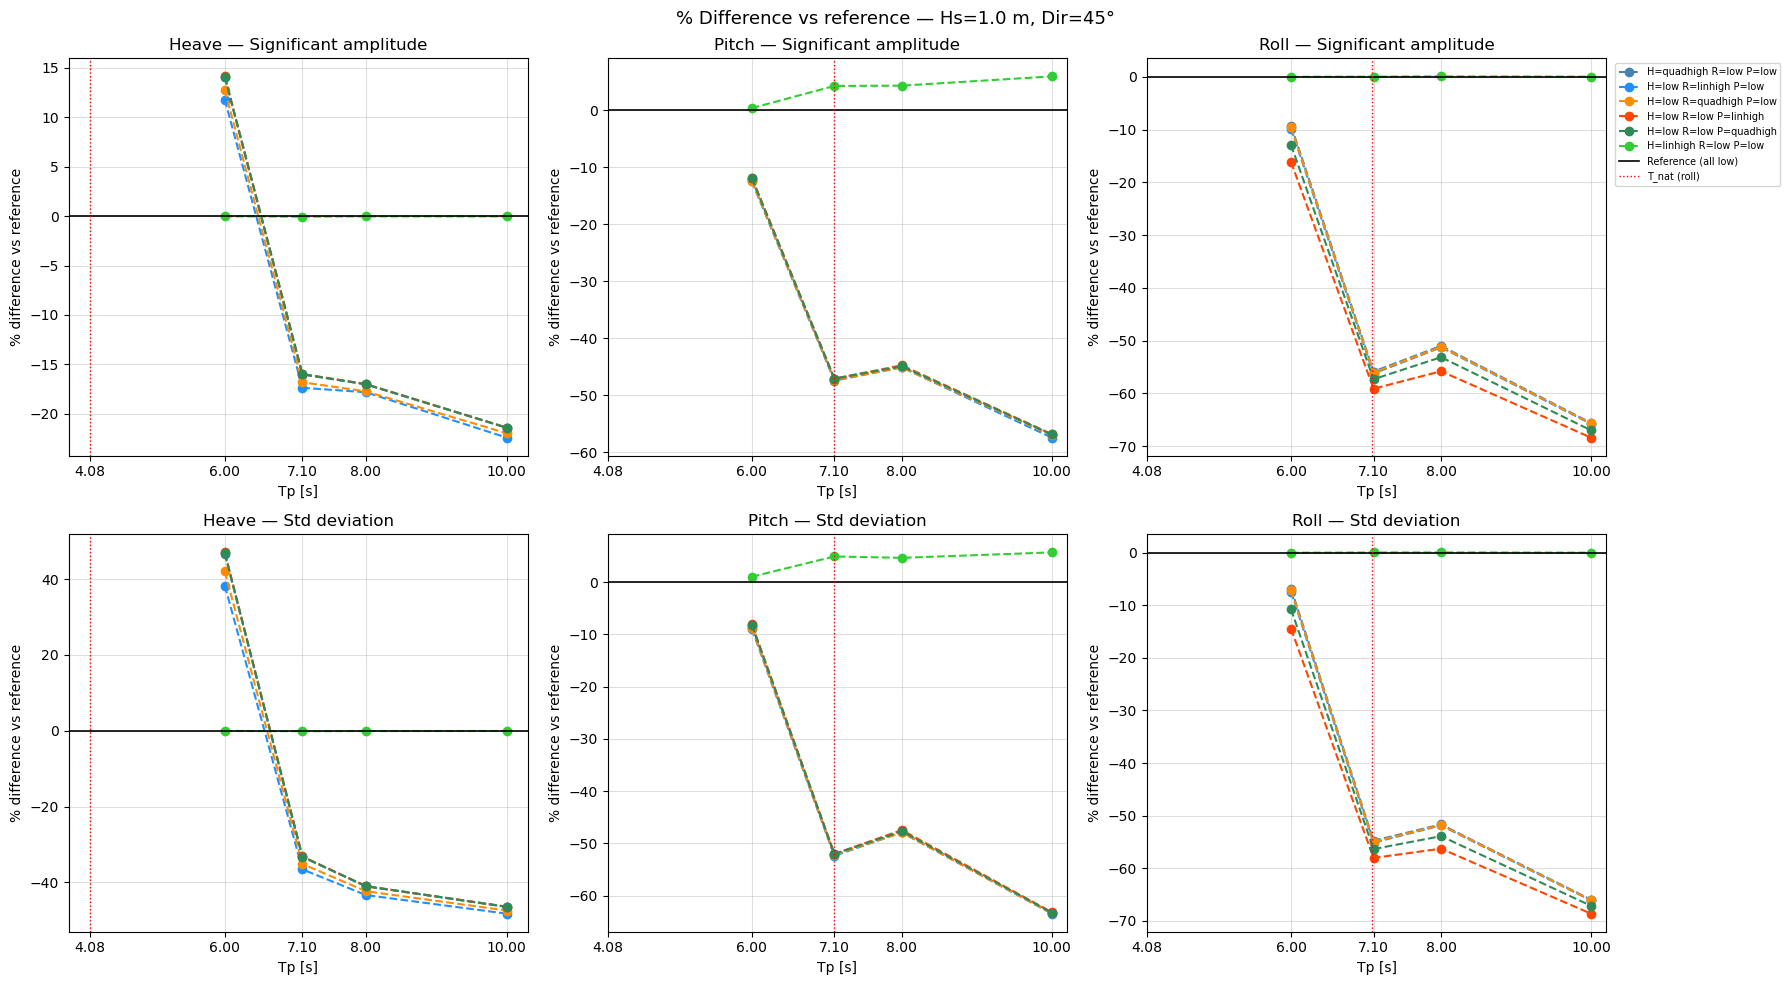

Saved: pct_vs_Tp_Hs1.0_dir45.png


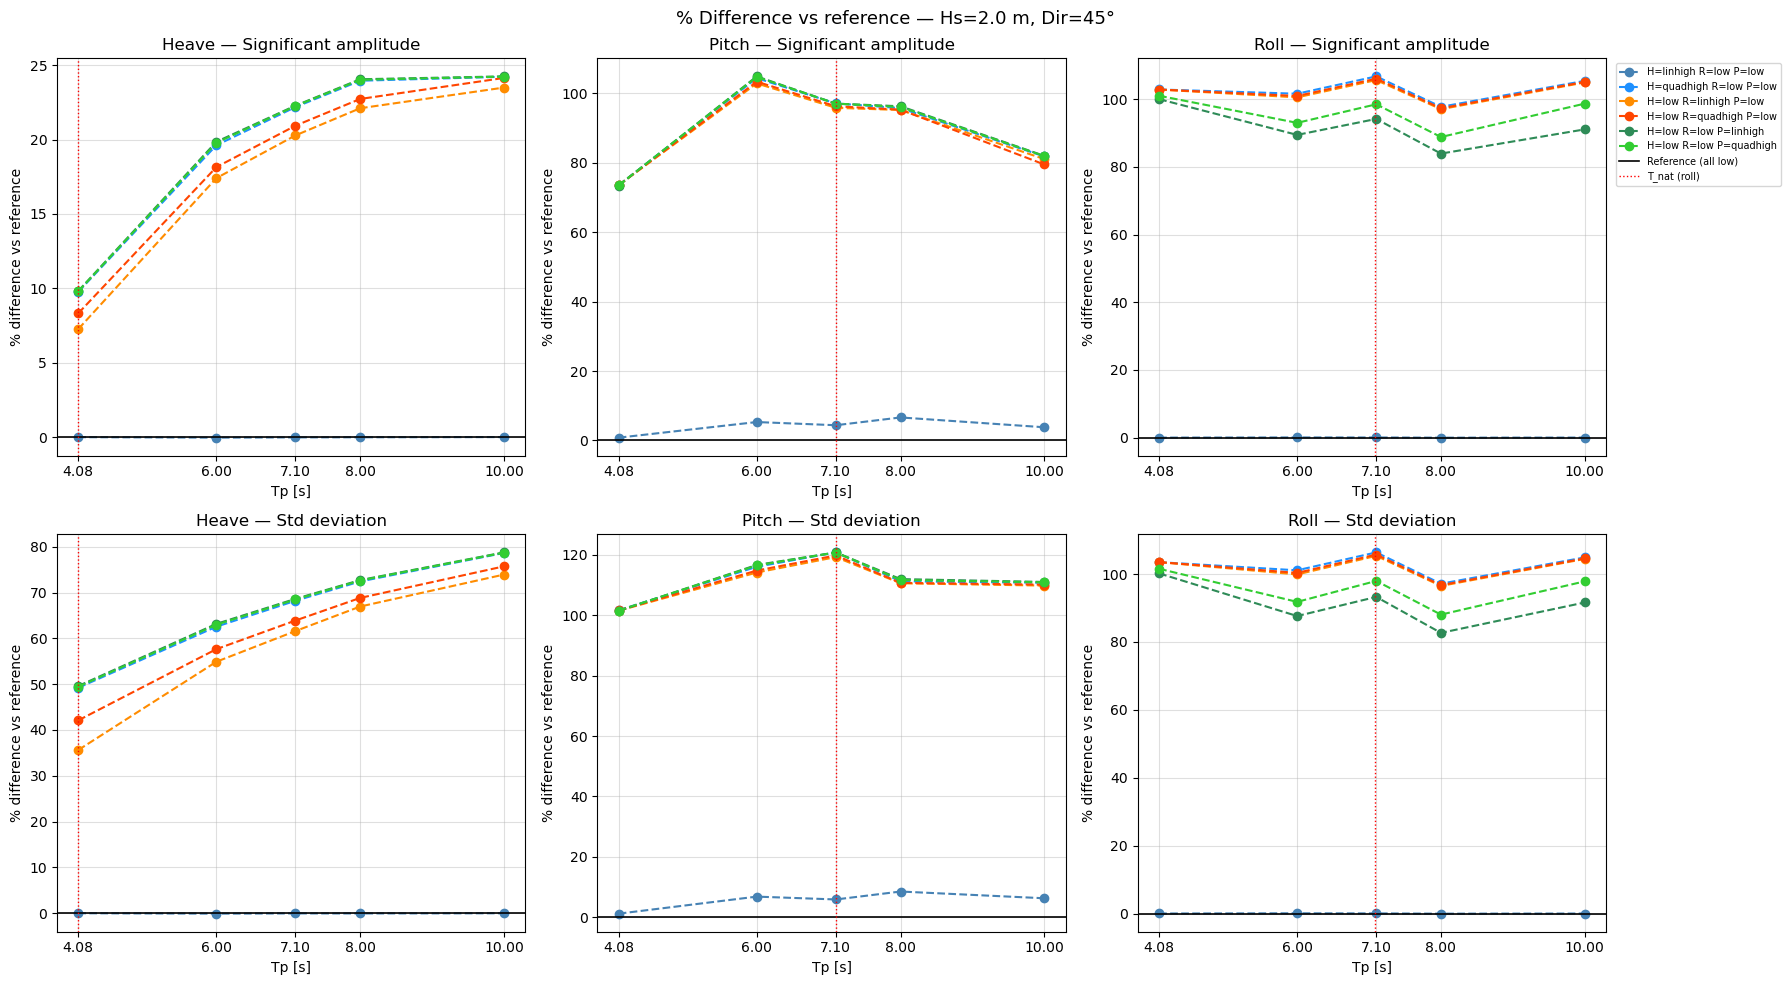

Saved: pct_vs_Tp_Hs2.0_dir45.png


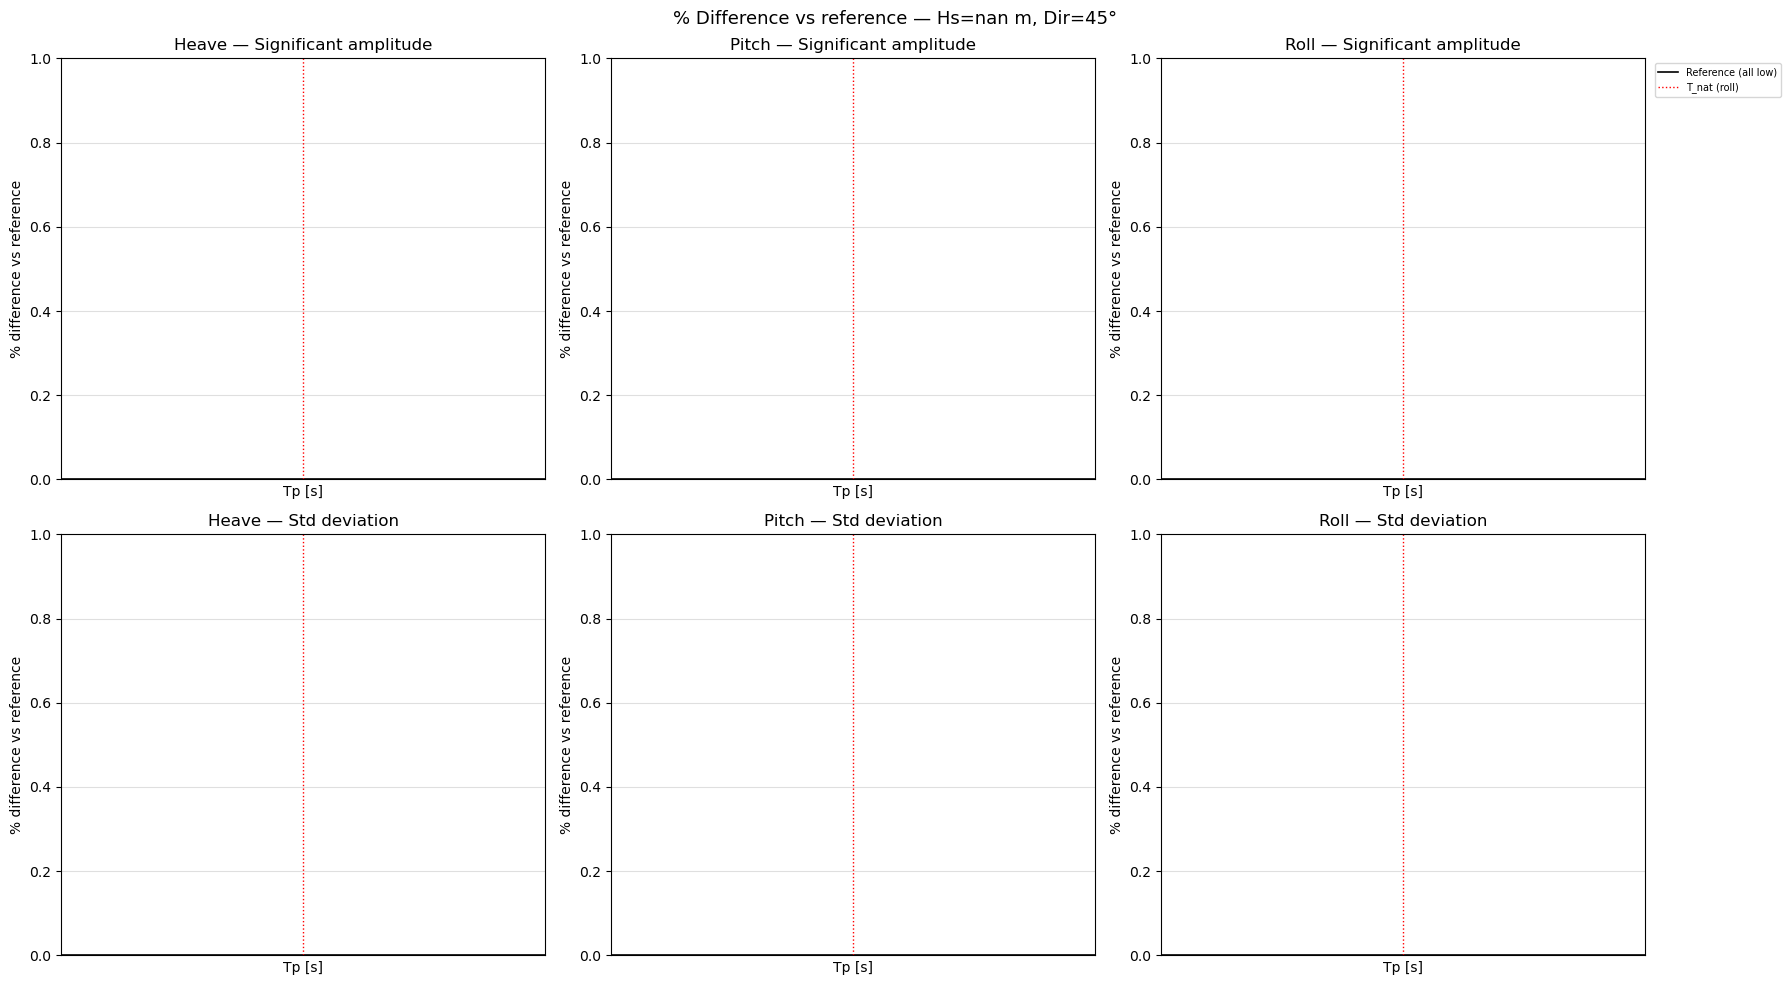

Saved: pct_vs_Tp_Hsnan_dir45.png


ValueError: cannot convert float NaN to integer

In [13]:
# ============================================================
# 14. % difference vs Tp — per dampingcase
#     One line per damping combination, x-axis = Tp
#     Y-axis = % difference vs reference (all low)
#     Separate plots per Hs, Direction, DOF
# ============================================================

dof_pairs = {
    'heave': ('heave_sig_amp_pct', 'heave_std_pct'),
    'pitch': ('pitch_sig_amp_pct', 'pitch_std_pct'),
    'roll':  ('roll_sig_amp_pct',  'roll_std_pct'),
}

dir_skip_dof = {
    0:  ['roll'],
    90: ['pitch'],
    45: [],
}

def damp_label_short(row):
    return f"H={row['Damp_Heave']} R={row['Damp_Roll']} P={row['Damp_Pitch']}"

damp_colors = [
    'steelblue',   # heave linhigh
    'dodgerblue',  # heave quadhigh
    'darkorange',  # roll linhigh
    'orangered',   # roll quadhigh
    'seagreen',    # pitch linhigh
    'limegreen',   # pitch quadhigh
]

# Natural periods — shown as vertical lines
nat_periods = {
    'heave': 4.08,
    'pitch': 7.10,
    'roll':  7.08,
}

for direction in sorted(results['Direction'].unique()):
    skip_dofs = dir_skip_dof.get(int(direction), [])

    for hs in sorted(results['Hs'].unique()):

        # Only non-reference cases
        subset = non_ref[
            (non_ref['Direction'] == direction) &
            (non_ref['Hs'] == hs)
        ].copy()
        subset['damp_label'] = subset.apply(damp_label_short, axis=1)
        damp_cases = subset['damp_label'].unique()

        active_dofs = {dof: cols for dof, cols in dof_pairs.items() if dof not in skip_dofs}
        n_dofs = len(active_dofs)

        fig, axes = plt.subplots(2, n_dofs, figsize=(6 * n_dofs, 10), sharey=False)
        if n_dofs == 1:
            axes = axes.reshape(2, 1)
        fig.suptitle(
            f'% Difference vs reference — Hs={hs} m, Dir={int(direction)}°',
            fontsize=13
        )

        tp_vals = sorted(subset['Tp'].unique())

        for col_idx, (dof, (sa_col, std_col)) in enumerate(active_dofs.items()):
            for row_idx, (metric_col, metric_label) in enumerate([
                (sa_col,  'Significant amplitude'),
                (std_col, 'Std deviation'),
            ]):
                ax = axes[row_idx][col_idx]

                for c_idx, damp_case in enumerate(damp_cases):
                    grp = subset[subset['damp_label'] == damp_case].sort_values('Tp')
                    ax.plot(
                        grp['Tp'],
                        grp[metric_col],
                        marker='o',
                        linewidth=1.5,
                        linestyle='--',
                        color=damp_colors[c_idx % len(damp_colors)],
                        label=damp_case,
                    )

                # Reference line at 0%
                ax.axhline(0, color='black', linewidth=1.2, linestyle='-', label='Reference (all low)')

                # Natural period vertical line for this DOF
                if dof in nat_periods:
                    ax.axvline(
                        nat_periods[dof],
                        color='red', linewidth=1.0, linestyle=':',
                        label=f'T_nat ({dof})'
                    )

                ax.set_title(f'{dof.capitalize()} — {metric_label}')
                ax.set_xlabel('Tp [s]')
                ax.set_ylabel('% difference vs reference')
                ax.set_xticks(tp_vals)
                ax.grid(True, alpha=0.4)

                if col_idx == n_dofs - 1 and row_idx == 0:
                    ax.legend(fontsize=7, bbox_to_anchor=(1.01, 1), loc='upper left')

        plt.tight_layout()
        fname = PLOTS_DIR / f'pct_vs_Tp_Hs{hs}_dir{int(direction)}.png'
        plt.savefig(fname, dpi=150, bbox_inches='tight')
        plt.show()
        plt.close()
        print(f'Saved: {fname.name}')

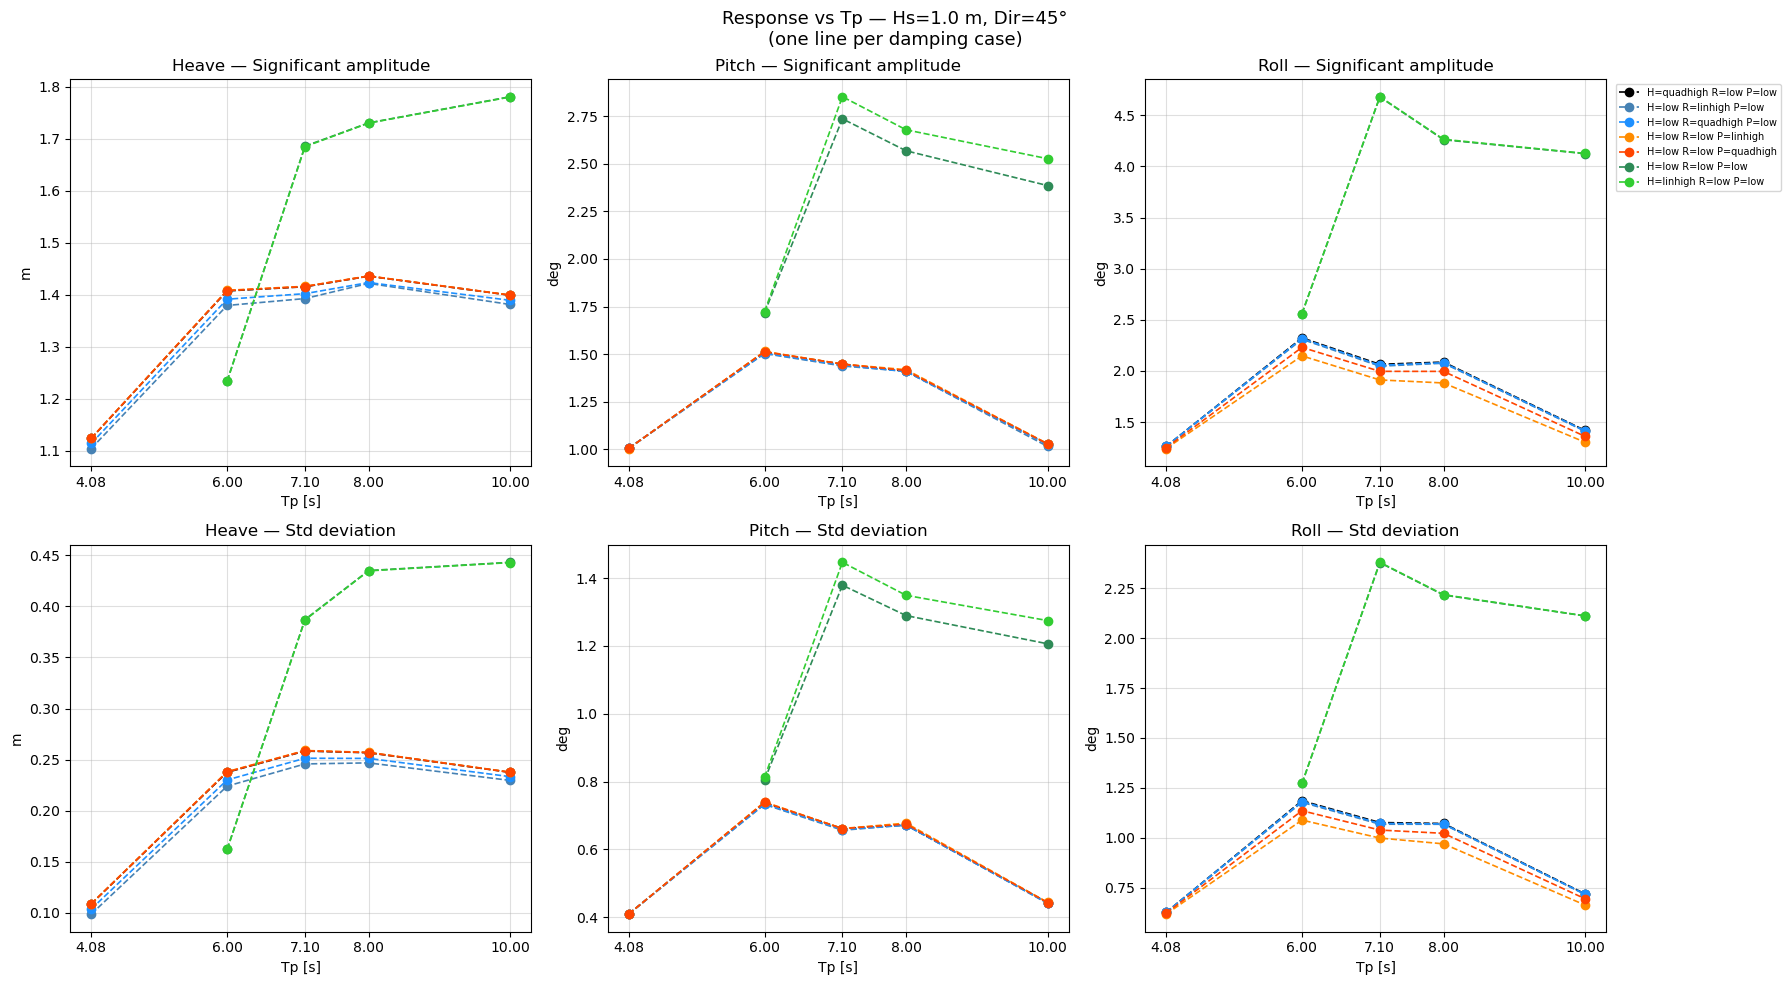

Saved: vs_Tp_Hs1.0_dir45.png


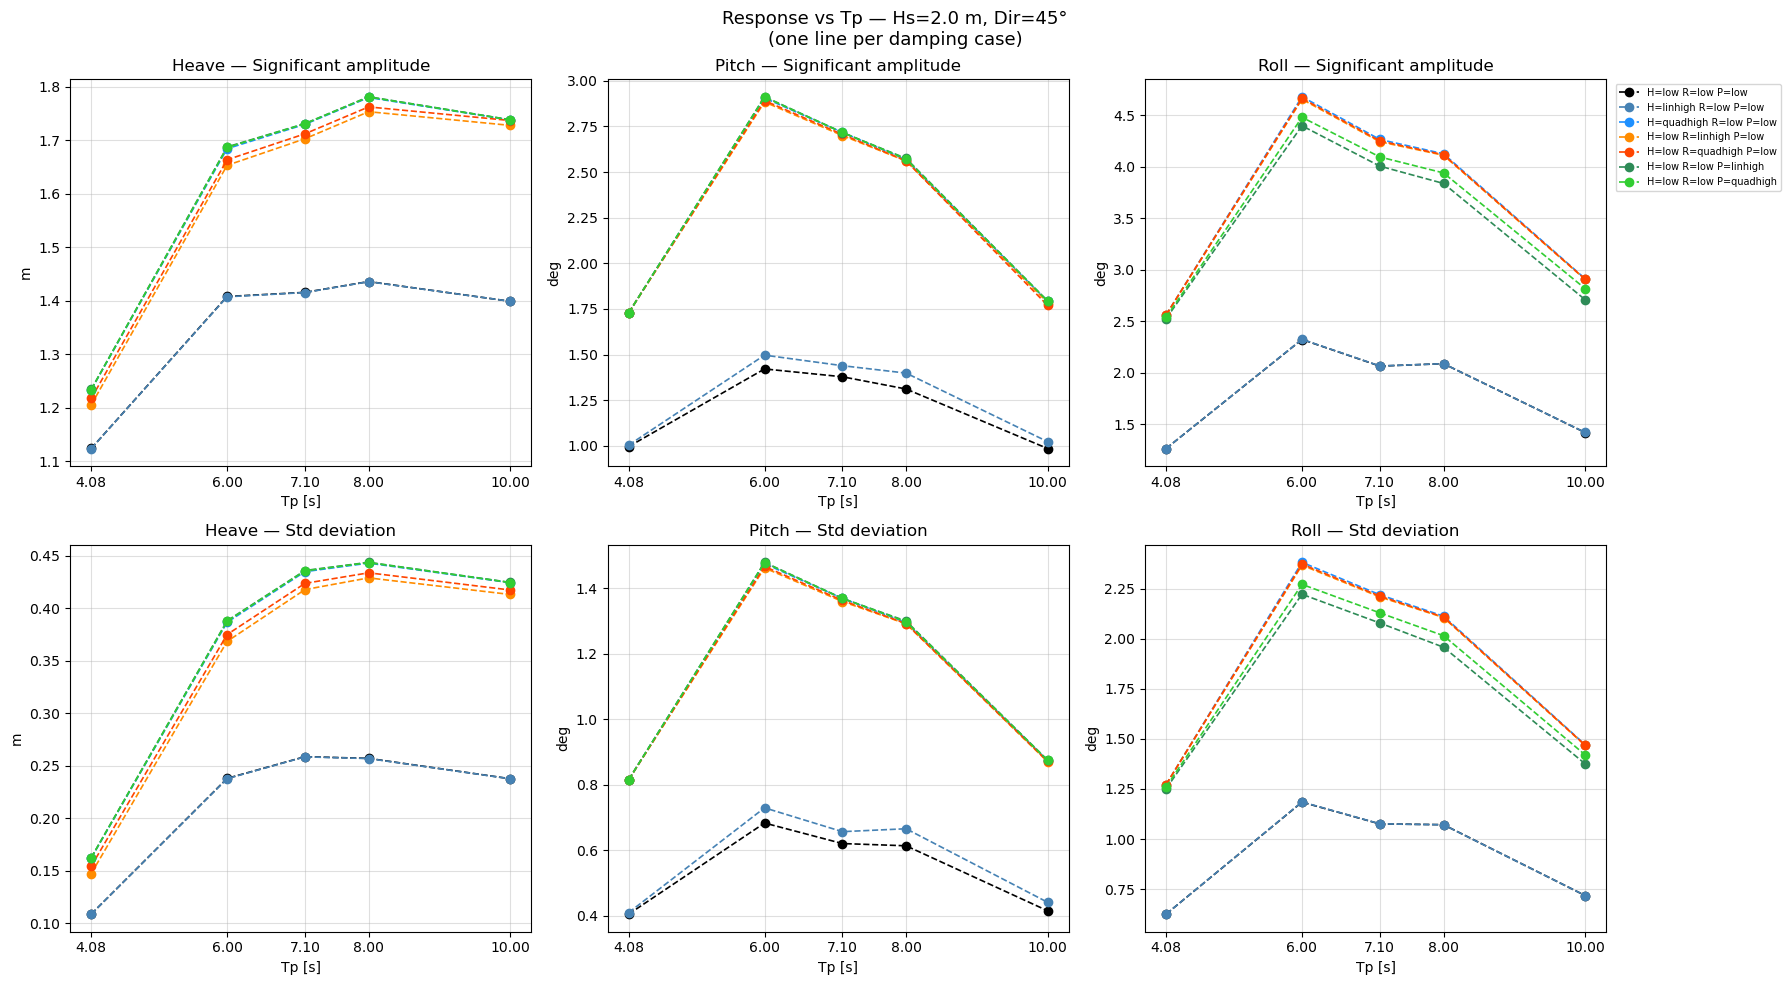

Saved: vs_Tp_Hs2.0_dir45.png


C:\Users\verav\AppData\Local\Temp\ipykernel_25768\814451686.py:88: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=7, bbox_to_anchor=(1.01, 1), loc='upper left')


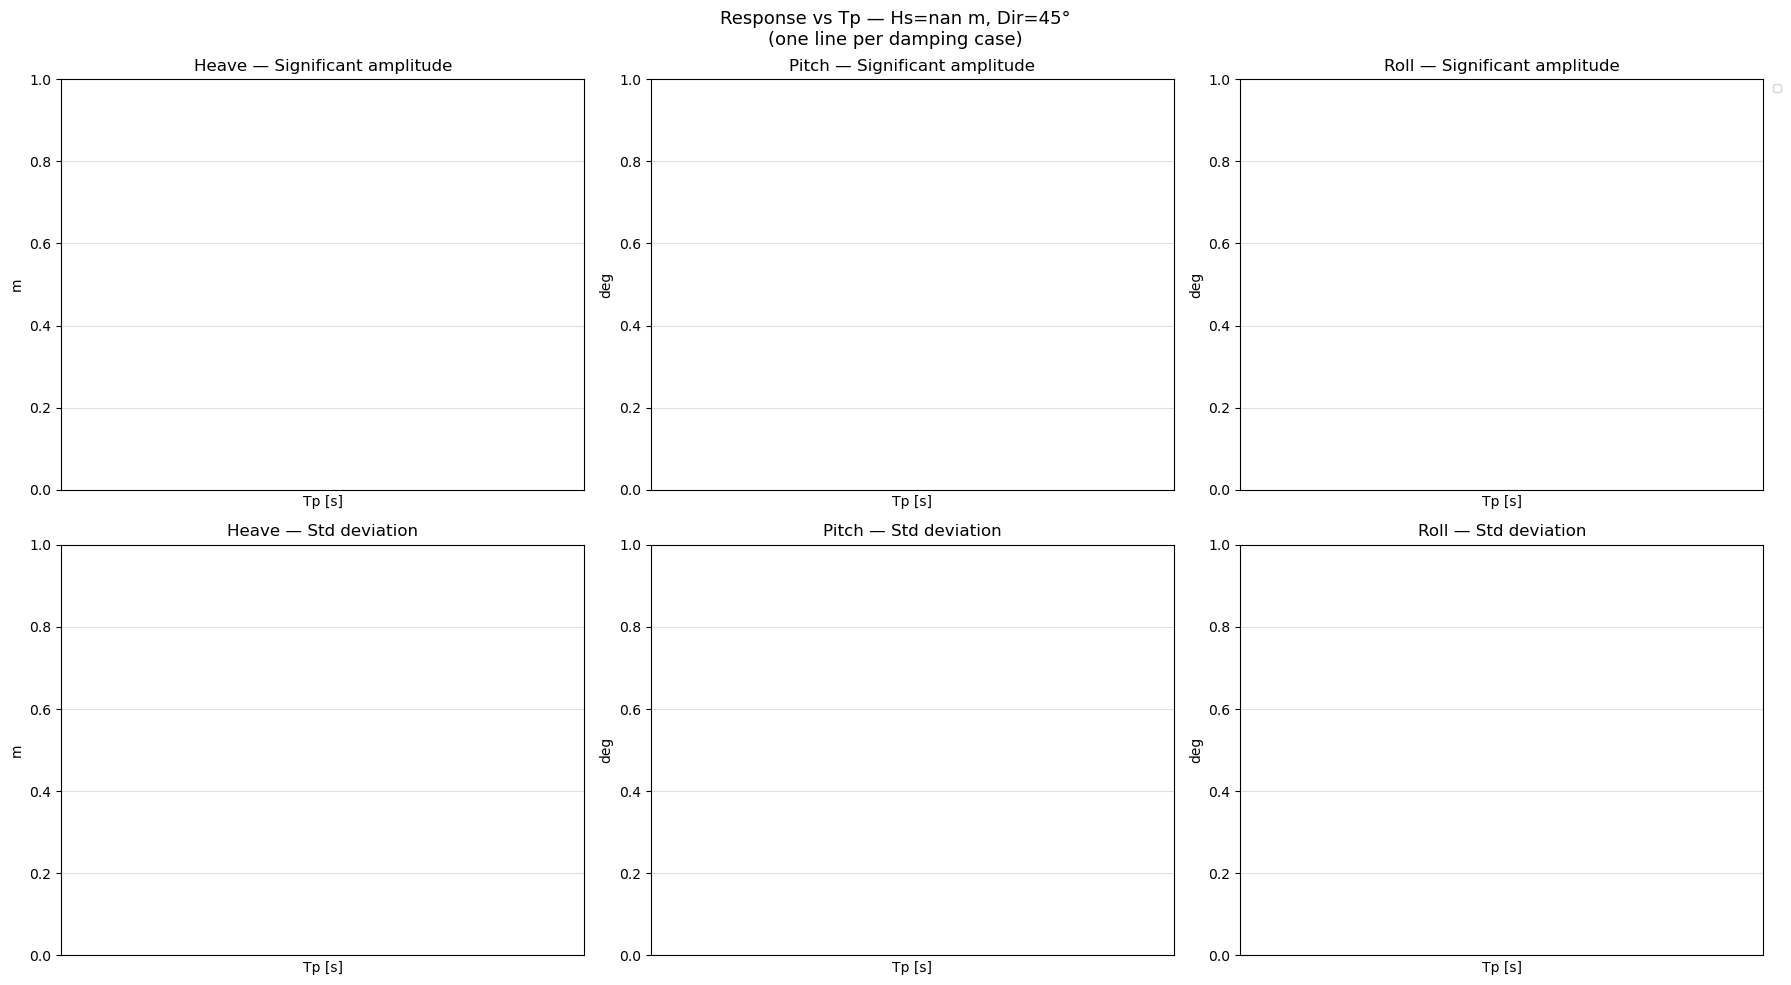

Saved: vs_Tp_Hsnan_dir45.png


ValueError: cannot convert float NaN to integer

In [ ]:
# ============================================================
# 14. Amplitude & std vs Tp — per dampingcase
#     One line per damping combination, x-axis = Tp
#     Separate plots per Hs, Direction, DOF
# ============================================================

dof_pairs = {
    'heave': ('heave_sig_amp', 'heave_std'),
    'pitch': ('pitch_sig_amp', 'pitch_std'),
    'roll':  ('roll_sig_amp',  'roll_std'),
}

# Direction filter (skip near-zero DOFs)
dir_skip_dof = {
    0:  ['roll'],
    90: ['pitch'],
    45: [],
}

# Damping case label
def damp_label_short(row):
    return f"H={row['Damp_Heave']} R={row['Damp_Roll']} P={row['Damp_Pitch']}"

# Color per damping case (7 cases)
damp_colors = [
    'black',       # low low low (reference)
    'steelblue',   # heave linhigh
    'dodgerblue',  # heave quadhigh
    'darkorange',  # roll linhigh
    'orangered',   # roll quadhigh
    'seagreen',    # pitch linhigh
    'limegreen',   # pitch quadhigh
]

for direction in results['Direction'].unique():
    skip_dofs = dir_skip_dof.get(int(direction), [])

    for hs in sorted(results['Hs'].unique()):
        subset = results[
            (results['Direction'] == direction) &
            (results['Hs'] == hs)
        ].copy()

        subset['damp_label'] = subset.apply(damp_label_short, axis=1)
        damp_cases = subset['damp_label'].unique()

        active_dofs = {dof: cols for dof, cols in dof_pairs.items() if dof not in skip_dofs}
        n_dofs = len(active_dofs)

        fig, axes = plt.subplots(2, n_dofs, figsize=(6 * n_dofs, 10), sharey=False)
        if n_dofs == 1:
            axes = axes.reshape(2, 1)
        fig.suptitle(
            f'Response vs Tp — Hs={hs} m, Dir={int(direction)}°\n'
            f'(one line per damping case)',
            fontsize=13
        )

        tp_vals = sorted(subset['Tp'].unique())

        for col_idx, (dof, (sa_col, std_col)) in enumerate(active_dofs.items()):
            for row_idx, (metric_col, metric_label) in enumerate([
                (sa_col,  'Significant amplitude'),
                (std_col, 'Std deviation'),
            ]):
                ax = axes[row_idx][col_idx]

                for c_idx, damp_case in enumerate(damp_cases):
                    grp = subset[subset['damp_label'] == damp_case].sort_values('Tp')
                    is_ref = 'low low low' in damp_case.replace('=', ' ')
                    ax.plot(
                        grp['Tp'],
                        grp[metric_col],
                        marker='o',
                        linewidth=2.0 if is_ref else 1.2,
                        linestyle='-' if is_ref else '--',
                        color=damp_colors[c_idx % len(damp_colors)],
                        label=damp_case,
                        zorder=3 if is_ref else 2,
                    )

                ax.set_title(f'{dof.capitalize()} — {metric_label}')
                ax.set_xlabel('Tp [s]')
                ax.set_ylabel('m' if dof == 'heave' else 'deg')
                ax.set_xticks(tp_vals)
                ax.grid(True, alpha=0.4)
                if col_idx == n_dofs - 1 and row_idx == 0:
                    ax.legend(fontsize=7, bbox_to_anchor=(1.01, 1), loc='upper left')

        plt.tight_layout()
        fname = PLOTS_DIR / f'vs_Tp_Hs{hs}_dir{int(direction)}.png'
        plt.savefig(fname, dpi=150, bbox_inches='tight')
        plt.show()
        plt.close()
        print(f'Saved: {fname.name}')

## Done!

**Output files:**
- `analysis/sensitivity_results_45deg.xlsx` — all 45° cases with sig. amplitude, std, and % differences
- `analysis/sensitivity_summary_45deg.xlsx` — mean |% difference| per varied DOF
- `analysis/plots/ts_*.png` — time series plots (200–300 s), all damping cases overlaid
- `analysis/plots/barchart_*.png` — % difference bar charts per seastate
- `analysis/plots/heatmap_summary.png` — overview heatmap
